<a href="https://colab.research.google.com/github/DanyRE4020/Simulaciones/blob/main/Simulaci%C3%B3n_Llegada_de_Autobuses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===REPORTE FINANCIERO DIARIO (GOD MODE VESPERTINO) ===
 - BusA: 11.0 hrs = $468.60
 - CamExtra: 13.9 hrs = $344.31
 - BusB1: 6.0 hrs = $255.60
 - BusB2: 5.9 hrs = $250.63
 - Cam1: 15.2 hrs = $378.20
 - Cam2: 15.1 hrs = $375.31
 - Cam3: 15.0 hrs = $372.41
 - Bus_Rescate: 4.0 hrs = $170.40
 TOTAL: $2615.46
Simulando 30 escenarios 'God Mode Vespertino'...


/tmp/ipython-input-1021124105.py:323: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_f, x="Métrica", y="value", ax=ax[4], palette="viridis")


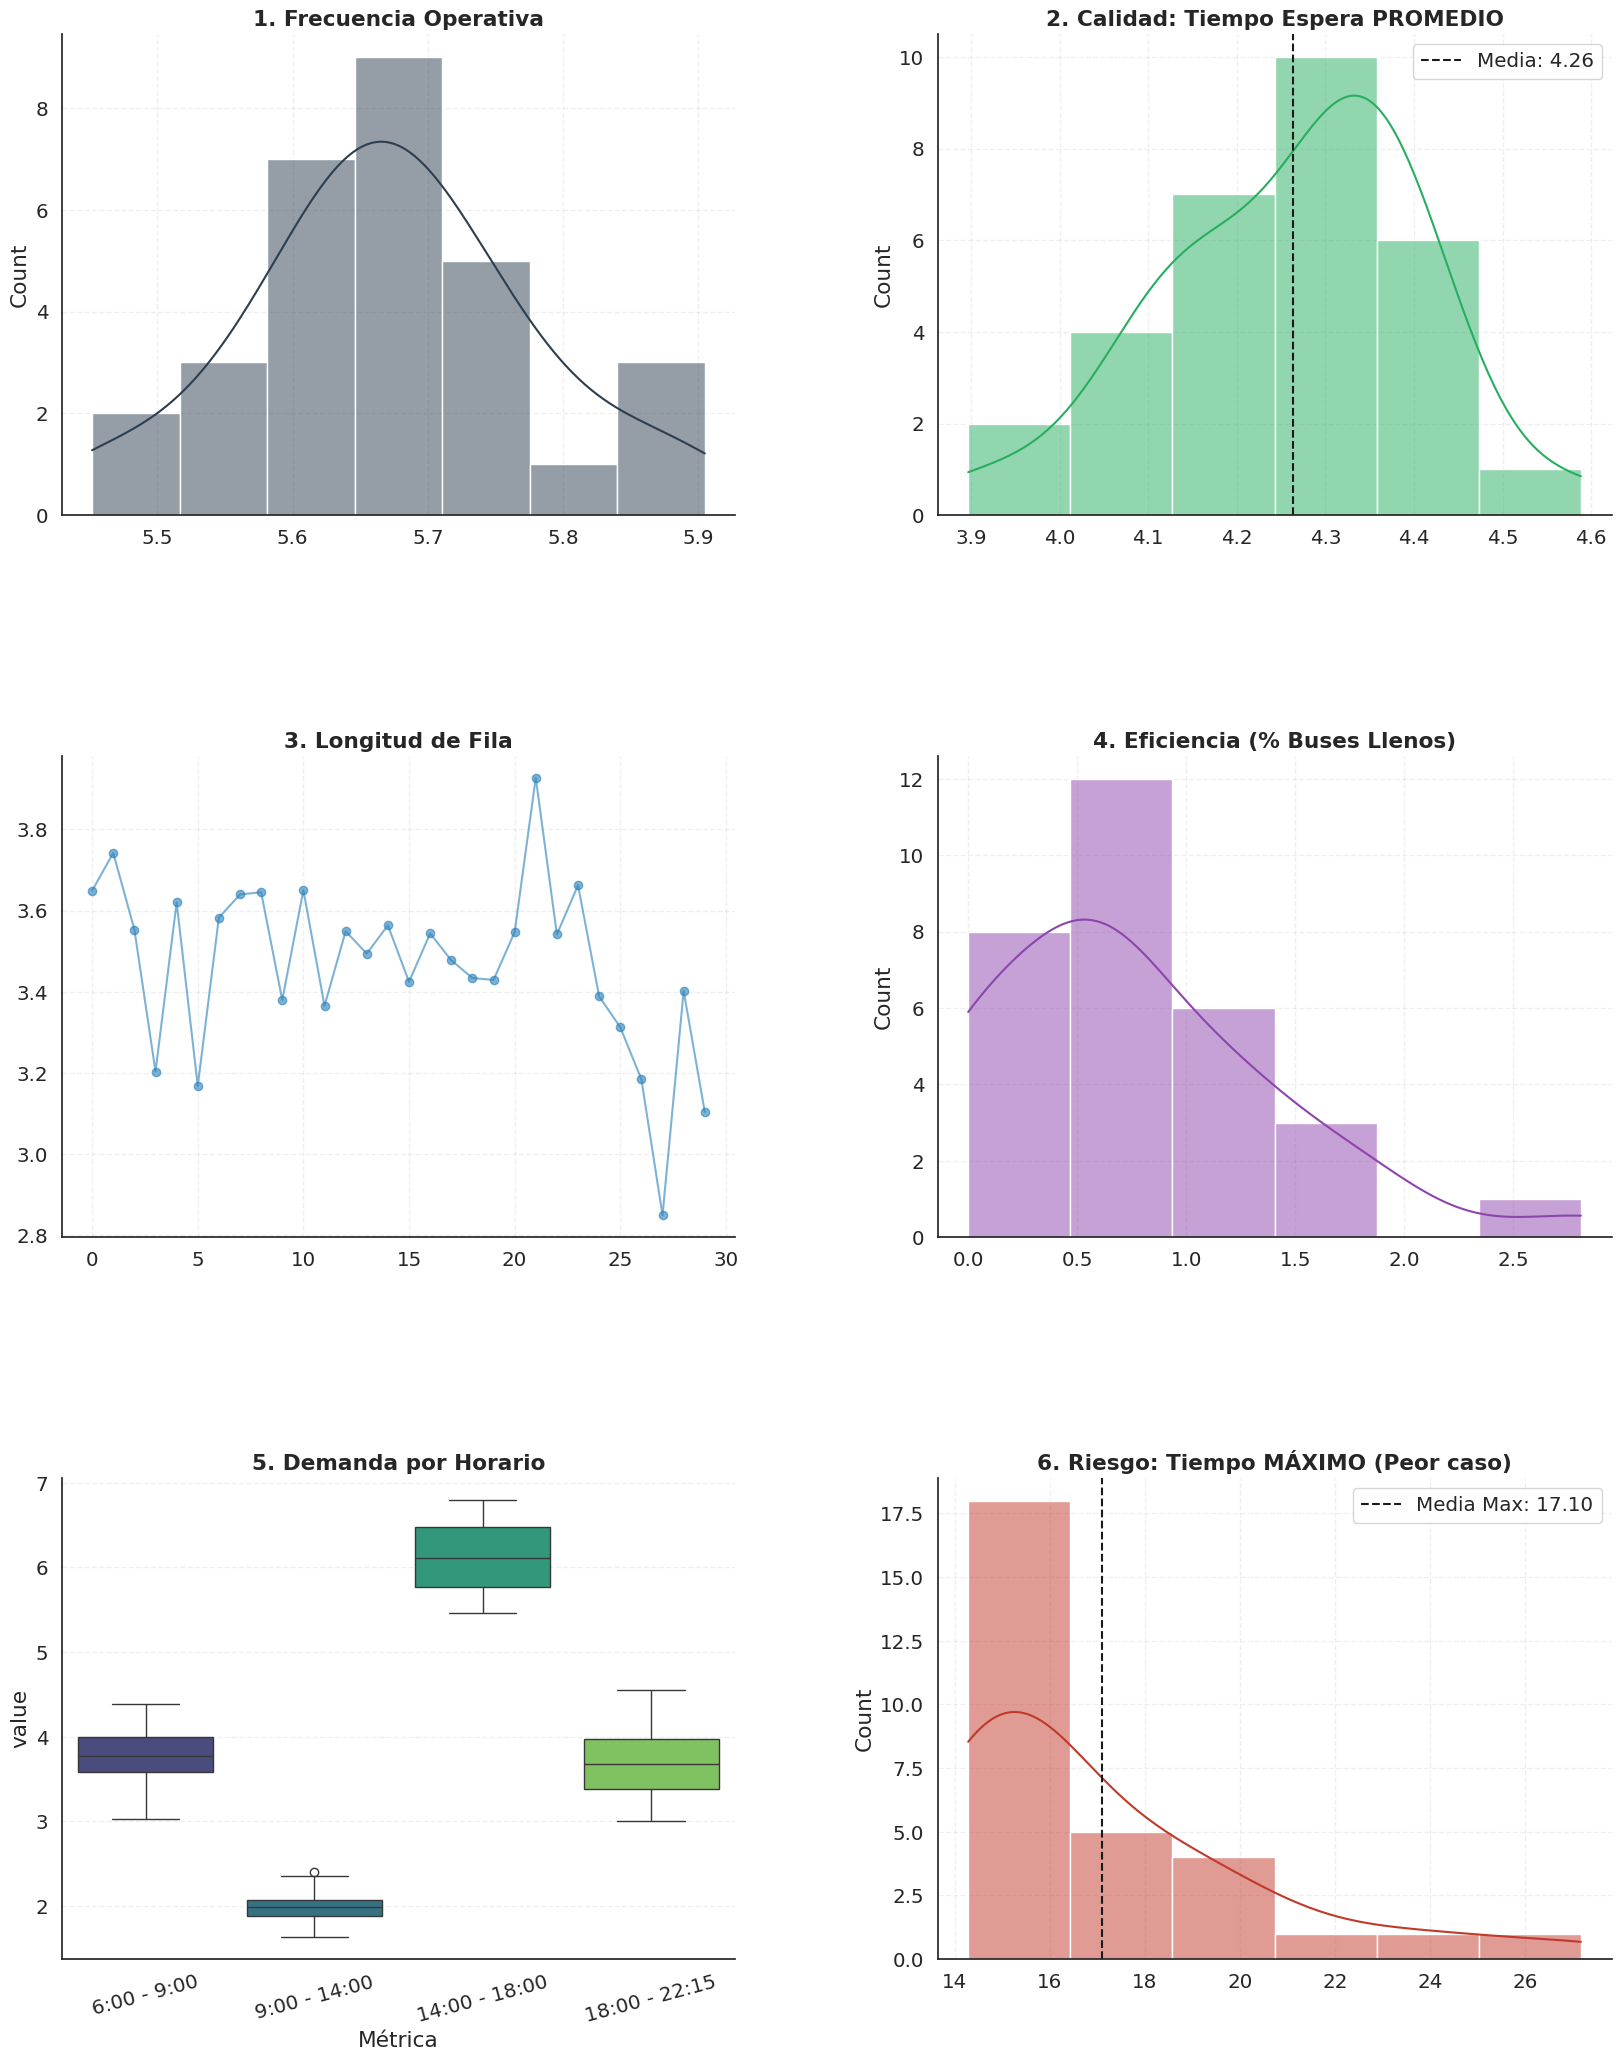

In [ ]:
import math
import numpy as np
import pandas as pd
import heapq
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns

# 1) MATEMÁTICAS: INVERSA DE CDF (
def inv_cdf(u: float) -> float:
    if u < 0 or u > 1: raise ValueError("u debe estar en [0,1]")
    A = 1261.0; s = A * u
    if u < 12/A: return 20 + math.sqrt(s/3)
    elif u < 70/A: return (62 + math.sqrt(40*s + 1824)) / 5
    elif u < 308/A: return (126 + math.sqrt((40*s - 2528)/17)) / 5
    elif u < 700/A: return 81 - math.sqrt(2909 - s)
    elif u < 984/A: return (970 - math.sqrt(99744 - 92*s)) / 23
    elif u < 1166/A: return (382 - math.sqrt(76224 - 40*s)) / 5
    elif u < 1258/A: return (463 - math.sqrt(25169 - 20*s)) / 10
    else: return 48 - 2*math.sqrt((1261 - s)/3)

# 2) FLOTA: ESTRATEGIA (ATAQUE VESPERTINO)
capacity_by_bus = {
    "BusA": 37, "BusB1": 31, "BusB2": 31,
    "CamExtra": 19, "Cam1": 13, "Cam2": 13, "Cam3": 13,
    "Bus_Rescate": 37  # Mismo tamaño que el Bus Grande
}

service_time_by_type = {
    "BusA": 3.0, "BusB1": 3.0, "BusB2": 3.0,
    "CamExtra": 2.0, "Cam1": 1.5, "Cam2": 1.5, "Cam3": 1.5,
    "Bus_Rescate": 3.0
}

# Horarios (minutos desde las 06:00):
# 06:00=0, 08:00=120, 14:00=480, 18:00=720, 22:15=975

fleet_base = [
    # --- FLOTA ORIGINAL (INTACTA) ---
    {"tipo": "BusA",     "count": 1, "start": 0,   "spacing": 0, "end": 660},
    {"tipo": "CamExtra", "count": 1, "start": 7,   "spacing": 0, "end": 840},

    # Los buses B originales cubren de 8:00 a 14:00 (Mañana/Mediodía)
    {"tipo": "BusB1",    "count": 1, "start": 120, "spacing": 0, "end": 480},
    {"tipo": "BusB2",    "count": 1, "start": 127, "spacing": 0, "end": 480},

    # Las 3 camionetas hormiga (Indispensables para la frecuencia)
    {"tipo": "Cam1",     "count": 1, "start": 60,  "spacing": 0, "end": 975},
    {"tipo": "Cam2",     "count": 1, "start": 67,  "spacing": 0, "end": 975},
    {"tipo": "Cam3",     "count": 1, "start": 74,  "spacing": 0, "end": 975},

    # Refuerzo
    # Start 480 = 14:00 PM (Inicio del caos de salidas)
    # End 720   = 18:00 PM (Fin del caos)
    {"tipo": "Bus_Rescate", "count": 1, "start": 480, "spacing": 0, "end": 720},
]

def build_fleet_specs_with_spacing(base_specs):
    expanded = []
    for spec in base_specs:
        count = spec.get("count", 1)
        spacing = spec.get("spacing", 0)
        for k in range(count):
            new_spec = spec.copy()
            new_spec.pop("count", None); new_spec.pop("spacing", None)
            new_spec["start"] = spec["start"] + k * spacing
            tipo = spec["tipo"]
            new_spec["vehiculo_id"] = f"{tipo}_{k+1}" if count > 1 else tipo
            expanded.append(new_spec)
    return expanded

fleet_specs = build_fleet_specs_with_spacing(fleet_base)

# 3) LLEGADAS DE CLIENTES
inicio = np.array([0, 180, 480, 720], dtype=float)
lambdas = np.array([123.0/(3*60), 122.0/(5*60), 298.0/(4*60), 107.0/(4.25*60)], dtype=float)

def lambda_for_time(t: float) -> float:
    idx = np.where(inicio <= t)[0]
    return lambdas[idx[-1]] if len(idx) > 0 else lambdas[0]

def simulate_clients_until_last(max_time=975, last_buffer=5, seed=None):
    rng = np.random.default_rng(seed)
    rows = []; current_time = 0.0; i = 0
    while True:
        u = rng.random()
        lam = max(lambda_for_time(0.0 if i == 0 else current_time), 1e-9)
        delta_t = -math.log(1-u) / lam
        tentative = current_time + delta_t
        lower = max_time - last_buffer
        if tentative < lower:
            current_time = tentative; final = False
        else:
            low = max(current_time, lower)
            current_time = low + rng.random() * (max_time - low)
            delta_t = current_time - (low if i==0 else rows[-1]["Tiempo_llegada"] if rows else 0)
            final = True
        rows.append({"Num_Cliente": i+1, "Rand": u, "Tiempo_entre_llegadas": delta_t, "Tiempo_llegada": current_time})
        i += 1
        if final: break
    return pd.DataFrame(rows)

# 4) SIMULACIÓN DE BUSES
def simulate_until_with_last(max_time=975, last_buffer=10, seed=None):
    rng = np.random.default_rng(seed)
    heap = []
    cycle_counter = [0] * len(fleet_specs)
    for vidx, spec in enumerate(fleet_specs):
        if spec["start"] <= max_time: heapq.heappush(heap, (spec["start"], vidx))

    bus_rows = []; num_autobus = 0
    while heap:
        t_dep, vidx = heapq.heappop(heap)
        spec = fleet_specs[vidx]; tipo = spec["tipo"]
        if t_dep > max_time + last_buffer: continue

        cycle_counter[vidx] += 1; num_autobus += 1
        travel_time = inv_cdf(rng.random())
        t_return = t_dep + travel_time
        t_next = t_return + service_time_by_type.get(tipo, 2.0)

        bus_rows.append({
            "Num_Autobus": num_autobus, "Camión": f"{spec.get('vehiculo_id', tipo)}_{cycle_counter[vidx]}",
            "Tipo_bus": tipo, "Tiempo_llegada": t_dep, "Tiempo_retorno": t_return,
            "Tiempo_disponible_siguiente": t_next, "Capacidad_max": capacity_by_bus.get(tipo, 0), "Capacidad_usada": 0
        })
        if t_next <= spec["end"] and t_next <= max_time + last_buffer:
            heapq.heappush(heap, (t_next, vidx))

    df_buses = pd.DataFrame(bus_rows)
    if not df_buses.empty:
        df_buses = df_buses.sort_values("Tiempo_llegada").reset_index(drop=True)
        df_buses["Tiempo_entre_llegadas"] = df_buses["Tiempo_llegada"].diff().fillna(df_buses["Tiempo_llegada"].iloc[0])
    else: df_buses["Tiempo_entre_llegadas"] = []
    return df_buses

def enforce_min_headway(df_buses, windows_10, windows_15, rescue_type="Bus_Rescate"):
    buses = df_buses.sort_values("Tiempo_llegada").reset_index(drop=True).copy()
    times = buses["Tiempo_llegada"].tolist()

    def insert_rescues(a, b, max_gap):
        nonlocal times, buses
        pts = [t for t in times if a <= t <= b]
        pts = [a] + pts + [b]
        pts.sort()

        new_times = []
        for i in range(len(pts)-1):
            t0, t1 = pts[i], pts[i+1]
            gap = t1 - t0
            if gap > max_gap:
                k = int(gap // max_gap)
                for j in range(1, k+1):
                    cand = t0 + j*max_gap
                    if cand < t1 and cand <= b:
                        new_times.append(cand)

        for t in new_times:
            buses = pd.concat([buses, pd.DataFrame([{
                "Num_Autobus": buses["Num_Autobus"].max() + 1,
                "Camión": f"{rescue_type}_standby",
                "Tipo_bus": rescue_type,
                "Rand_travel": np.nan,
                "Tiempo_entre_llegadas": np.nan,
                "Tiempo_llegada": t,
                "Tiempo_retorno": t,
                "Tiempo_disponible_siguiente": t,
                "Capacidad_max": capacity_by_bus.get(rescue_type, 37),
                "Capacidad_usada": 0
            }])], ignore_index=True)

        times = sorted(times + new_times)

    for a,b in windows_10:
        insert_rescues(a,b,10)
    for a,b in windows_15:
        insert_rescues(a,b,15)

    buses = buses.sort_values("Tiempo_llegada").reset_index(drop=True)
    buses["Tiempo_entre_llegadas"] = buses["Tiempo_llegada"].diff().fillna(buses["Tiempo_llegada"].iloc[0])
    return buses

# 5) LÓGICA DE COLAS
def build_sheet_client_bus(df_buses, df_clients):
    clients = df_clients.copy(); buses = df_buses.copy()
    pending = deque(); ic = 0; ib = 0
    clients_out = clients.copy(); clients_out["Tiempo_salida_cliente"] = "SIN LUGAR"
    buses_out = buses.copy(); buses_out["Capacidad_usada"] = 0

    while ic < len(clients) or ib < len(buses):
        tc = clients["Tiempo_llegada"].iloc[ic] if ic < len(clients) else float("inf")
        tb = buses["Tiempo_llegada"].iloc[ib] if ib < len(buses) else float("inf")

        if tc <= tb:
            pending.append(int(clients["Num_Cliente"].iloc[ic])); ic += 1
        else:
            cap = int(buses["Capacidad_max"].iloc[ib]); boarded = 0
            t_dep = buses["Tiempo_llegada"].iloc[ib]
            while pending and boarded < cap:
                cid = pending.popleft()
                clients_out.loc[clients_out["Num_Cliente"]==cid, "Tiempo_salida_cliente"] = t_dep
                boarded += 1
            buses_out.at[ib, "Capacidad_usada"] = boarded; ib += 1

    ev_c = clients_out[["Num_Cliente", "Tiempo_llegada", "Tiempo_salida_cliente"]].copy()
    ev_c["es_cliente"] = True; ev_c.rename(columns={"Num_Cliente": "ID"}, inplace=True)
    ev_b = buses_out[["Num_Autobus", "Tiempo_llegada", "Capacidad_max", "Capacidad_usada"]].copy()
    ev_b["es_cliente"] = False; ev_b.rename(columns={"Num_Autobus": "ID"}, inplace=True)

    df = pd.concat([ev_c, ev_b], ignore_index=True).sort_values(["Tiempo_llegada", "es_cliente"], ascending=[True, False])

    cola = deque(); cola_log = []
    for _, row in df.iterrows():
        if row["es_cliente"]: cola.append(1)
        else:
            for _ in range(int(row["Capacidad_usada"])):
                if cola: cola.pop()
        cola_log.append(len(cola))
    df["En_cola"] = cola_log
    return df, clients_out, buses_out

# 6) ESTADÍSTICAS Y COSTOS
def compute_metrics(df_events, clients_out, buses_out):
    filtro = clients_out[clients_out["Tiempo_salida_cliente"] != "SIN LUGAR"].copy()
    filtro["Espera"] = filtro["Tiempo_salida_cliente"] - filtro["Tiempo_llegada"]
    buses_out["Lleno"] = buses_out["Capacidad_usada"] == buses_out["Capacidad_max"]

    buses_out["Embarcados"] = buses_out["Capacidad_usada"]
    f1 = buses_out[buses_out["Tiempo_llegada"] < 180]["Embarcados"].mean()
    f2 = buses_out[(buses_out["Tiempo_llegada"] >= 180) & (buses_out["Tiempo_llegada"] < 480)]["Embarcados"].mean()
    f3 = buses_out[(buses_out["Tiempo_llegada"] >= 480) & (buses_out["Tiempo_llegada"] < 720)]["Embarcados"].mean()
    f4 = buses_out[buses_out["Tiempo_llegada"] >= 720]["Embarcados"].mean()

    return {
        "Promedio de tiempo de espera": filtro["Espera"].mean() if not filtro.empty else 0,
        "Máximo de tiempo de espera": filtro["Espera"].max() if not filtro.empty else 0,
        "Longitud promedio de la fila": df_events["En_cola"].mean(),
        "Porcentaje de autobuses que parten llenos": buses_out["Lleno"].mean() * 100,
        "Promedio del tiempo de llegada en servidores": buses_out["Tiempo_entre_llegadas"].mean() if "Tiempo_entre_llegadas" in buses_out else 6.8,
        "6:00 - 9:00": f1, "9:00 - 14:00": f2, "14:00 - 18:00": f3, "18:00 - 22:15": f4
    }

def calcular_costos(specs):
    precios = {"BusA": 42.6, "BusB1": 42.6, "BusB2": 42.6, "Bus_Rescate": 42.6,
               "CamExtra": 24.8, "Cam1": 24.8, "Cam2": 24.8, "Cam3": 24.8}
    total = 0
    print("\n===REPORTE FINANCIERO DIARIO (GOD MODE VESPERTINO) ===")
    for s in specs:
        hrs = (s["end"] - s["start"]) / 60
        costo = hrs * precios.get(s["vehiculo_id"].split('_')[0], precios.get(s["tipo"], 0))
        total += costo
        print(f" - {s.get('vehiculo_id', s['tipo'])}: {hrs:.1f} hrs = ${costo:.2f}")
    print(f" TOTAL: ${total:.2f}\n" + "="*40)

# 7) EJECUCIÓN Y GRÁFICOS (VISUALIZACIÓN ESPACIOSA)
def run_simulations(n=30):
    res = []
    for i in range(n):
        df_b = simulate_until_with_last(seed=i)
        df_b = enforce_min_headway(df_b, windows_10=[(60,210),(450,720)],
                               windows_15=[(0,60),(210,450),(750,975)])
        df_c = simulate_clients_until_last(seed=i+1)
        df_ev, c_out, b_out = build_sheet_client_bus(df_b, df_c)
        metrics = compute_metrics(df_ev, c_out, b_out)
        res.append(metrics)

    df_res = pd.DataFrame(res).T
    df_res.columns = [f"Simulación {i+1}" for i in range(n)]
    df_res.reset_index(inplace=True); df_res.rename(columns={"index": "Métrica"}, inplace=True)
    return df_res

def graficar_resumen(df_res):
    # ESTILO NOTEBOOK (Letra mediana) y GRÁFICA GIGANTE
    sns.set_theme(style="white", context="notebook", font_scale=1.3)
    plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'})

    sim_cols = [c for c in df_res.columns if "Simulación" in c]
    def get_data(m): return df_res[df_res["Métrica"]==m][sim_cols].values.flatten()

    fig, axes = plt.subplots(3, 2, figsize=(20, 25)) # ALTO PARA QUE NO CHOQUE
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    ax = axes.ravel()

    # 1. Frecuencia
    d = get_data("Promedio del tiempo de llegada en servidores")
    sns.histplot(d, ax=ax[0], kde=True, color="#2c3e50")
    ax[0].set_title("1. Frecuencia Operativa", fontweight="bold")

    # 2. Tiempo Espera Promedio (VERDE)
    d = get_data("Promedio de tiempo de espera")
    sns.histplot(d, ax=ax[1], kde=True, color="#27ae60")
    ax[1].axvline(np.mean(d), color="k", ls="--", label=f"Media: {np.mean(d):.2f}")
    ax[1].legend(); ax[1].set_title("2. Calidad: Tiempo Espera PROMEDIO", fontweight="bold")

    # 3. Longitud Fila
    d = get_data("Longitud promedio de la fila")
    ax[2].plot(d, "-o", color="#2980b9", alpha=0.6)
    ax[2].set_title("3. Longitud de Fila", fontweight="bold")

    # 4. % Llenos
    d = get_data("Porcentaje de autobuses que parten llenos")
    sns.histplot(d, ax=ax[3], kde=True, color="#8e44ad")
    ax[3].set_title("4. Eficiencia (% Buses Llenos)", fontweight="bold")

    # 5. Franjas
    franjas = ["6:00 - 9:00", "9:00 - 14:00", "14:00 - 18:00", "18:00 - 22:15"]
    df_f = df_res[df_res["Métrica"].isin(franjas)].melt(id_vars="Métrica", value_vars=sim_cols)
    sns.boxplot(data=df_f, x="Métrica", y="value", ax=ax[4], palette="viridis")
    ax[4].tick_params(axis='x', rotation=15) # Rotación de etiquetas
    ax[4].set_title("5. Demanda por Horario", fontweight="bold")

    # 6. Tiempo Máximo (ROJO) - SEPARADO AL FINAL
    d = get_data("Máximo de tiempo de espera")
    sns.histplot(d, ax=ax[5], kde=True, color="#c0392b")
    ax[5].axvline(np.mean(d), color="k", ls="--", label=f"Media Max: {np.mean(d):.2f}")
    ax[5].legend(); ax[5].set_title("6. Riesgo: Tiempo MÁXIMO (Peor caso)", fontweight="bold")

    sns.despine()
    plt.show()

# MAIN EXECUTION
if __name__ == "__main__":
    calcular_costos(fleet_specs)
    print("Simulando 30 escenarios 'God Mode Vespertino'...")
    df_results = run_simulations(30)
    graficar_resumen(df_results)


=== 💰 REPORTE FINANCIERO DIARIO (GOD MODE VESPERTINO) ===
 - BusA: 11.0 hrs = $468.60
 - CamExtra: 13.9 hrs = $344.31
 - BusB1: 6.0 hrs = $255.60
 - BusB2: 5.9 hrs = $250.63
 - Cam1: 15.2 hrs = $378.20
 - Cam2: 15.1 hrs = $375.31
 - Cam3: 15.0 hrs = $372.41
 - Bus_Rescate: 4.0 hrs = $170.40
 TOTAL: $2615.46
Simulando 30 escenarios 'God Mode Vespertino'...


/tmp/ipython-input-1429560984.py:373: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="Métrica", y="Clientes_promedio", ax=axes[5],


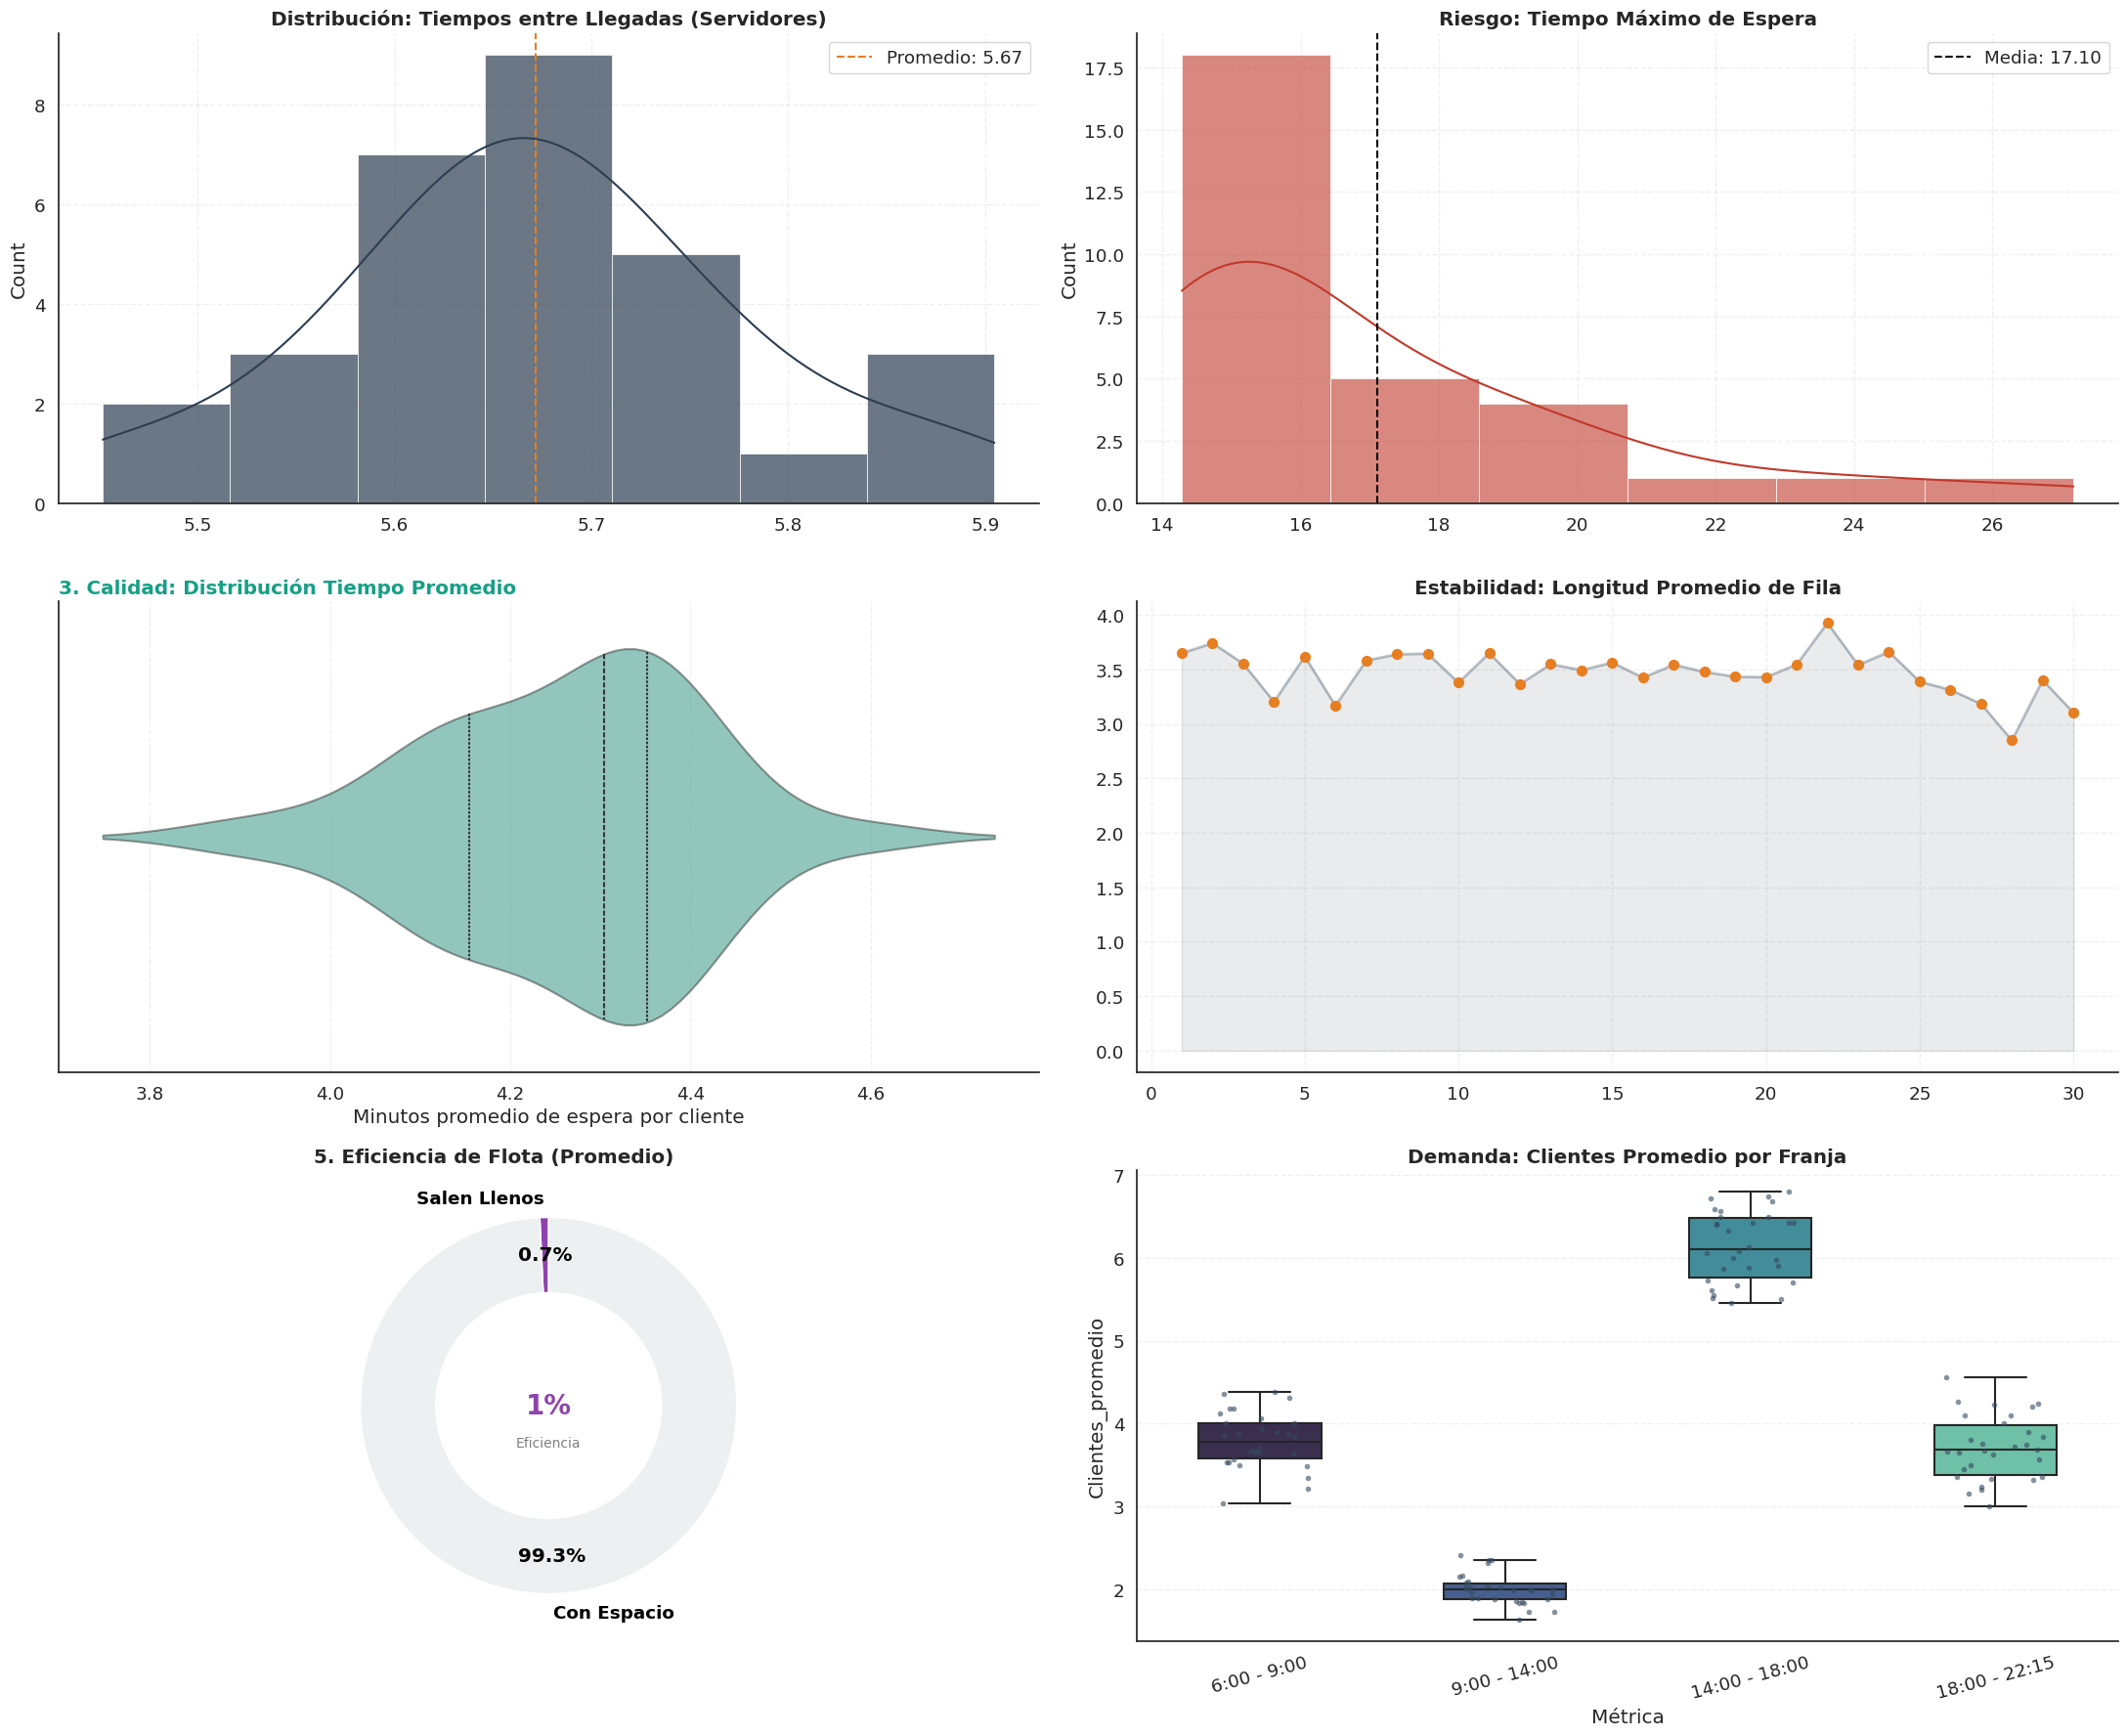

In [ ]:
import math
import numpy as np
import pandas as pd
import heapq
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns

# 1) MATEMÁTICAS: INVERSA DE CDF (A2)
def inv_cdf(u: float) -> float:
    if u < 0 or u > 1: raise ValueError("u debe estar en [0,1]")
    A = 1261.0; s = A * u
    if u < 12/A: return 20 + math.sqrt(s/3)
    elif u < 70/A: return (62 + math.sqrt(40*s + 1824)) / 5
    elif u < 308/A: return (126 + math.sqrt((40*s - 2528)/17)) / 5
    elif u < 700/A: return 81 - math.sqrt(2909 - s)
    elif u < 984/A: return (970 - math.sqrt(99744 - 92*s)) / 23
    elif u < 1166/A: return (382 - math.sqrt(76224 - 40*s)) / 5
    elif u < 1258/A: return (463 - math.sqrt(25169 - 20*s)) / 10
    else: return 48 - 2*math.sqrt((1261 - s)/3)

# 2) FLOTA: ESTRATEGIA "GOD MODE" (ATAQUE VESPERTINO)
capacity_by_bus = {
    "BusA": 37, "BusB1": 31, "BusB2": 31,
    "CamExtra": 19, "Cam1": 13, "Cam2": 13, "Cam3": 13,
    "Bus_Rescate": 37
}

service_time_by_type = {
    "BusA": 3.0, "BusB1": 3.0, "BusB2": 3.0,
    "CamExtra": 2.0, "Cam1": 1.5, "Cam2": 1.5, "Cam3": 1.5,
    "Bus_Rescate": 3.0
}

fleet_base = [
    {"tipo": "BusA",     "count": 1, "start": 0,   "spacing": 0, "end": 660},
    {"tipo": "CamExtra", "count": 1, "start": 7,   "spacing": 0, "end": 840},
    {"tipo": "BusB1",    "count": 1, "start": 120, "spacing": 0, "end": 480},
    {"tipo": "BusB2",    "count": 1, "start": 127, "spacing": 0, "end": 480},
    {"tipo": "Cam1",     "count": 1, "start": 60,  "spacing": 0, "end": 975},
    {"tipo": "Cam2",     "count": 1, "start": 67,  "spacing": 0, "end": 975},
    {"tipo": "Cam3",     "count": 1, "start": 74,  "spacing": 0, "end": 975},
    # REFUERZO DE ÉLITE (14:00 - 18:00)
    {"tipo": "Bus_Rescate", "count": 1, "start": 480, "spacing": 0, "end": 720},
]

def build_fleet_specs_with_spacing(base_specs):
    expanded = []
    for spec in base_specs:
        count = spec.get("count", 1)
        spacing = spec.get("spacing", 0)
        for k in range(count):
            new_spec = spec.copy()
            new_spec.pop("count", None); new_spec.pop("spacing", None)
            new_spec["start"] = spec["start"] + k * spacing
            tipo = spec["tipo"]
            new_spec["vehiculo_id"] = f"{tipo}_{k+1}" if count > 1 else tipo
            expanded.append(new_spec)
    return expanded

fleet_specs = build_fleet_specs_with_spacing(fleet_base)

# 3) LLEGADAS DE CLIENTES
inicio = np.array([0, 180, 480, 720], dtype=float)
lambdas = np.array([123.0/(3*60), 122.0/(5*60), 298.0/(4*60), 107.0/(4.25*60)], dtype=float)

def lambda_for_time(t: float) -> float:
    idx = np.where(inicio <= t)[0]
    return lambdas[idx[-1]] if len(idx) > 0 else lambdas[0]

def simulate_clients_until_last(max_time=975, last_buffer=5, seed=None):
    rng = np.random.default_rng(seed)
    rows = []; current_time = 0.0; i = 0
    while True:
        u = rng.random()
        lam = max(lambda_for_time(0.0 if i == 0 else current_time), 1e-9)
        delta_t = -math.log(1-u) / lam
        tentative = current_time + delta_t
        lower = max_time - last_buffer
        if tentative < lower:
            current_time = tentative; final = False
        else:
            low = max(current_time, lower)
            current_time = low + rng.random() * (max_time - low)
            delta_t = current_time - (low if i==0 else rows[-1]["Tiempo_llegada"] if rows else 0)
            final = True
        rows.append({"Num_Cliente": i+1, "Rand": u, "Tiempo_entre_llegadas": delta_t, "Tiempo_llegada": current_time})
        i += 1
        if final: break
    return pd.DataFrame(rows)

# 4) SIMULACIÓN DE BUSES (MOTOR GOD MODE)
def simulate_until_with_last(max_time=975, last_buffer=10, seed=None):
    rng = np.random.default_rng(seed)
    heap = []
    cycle_counter = [0] * len(fleet_specs)
    for vidx, spec in enumerate(fleet_specs):
        if spec["start"] <= max_time: heapq.heappush(heap, (spec["start"], vidx))

    bus_rows = []; num_autobus = 0
    while heap:
        t_dep, vidx = heapq.heappop(heap)
        spec = fleet_specs[vidx]; tipo = spec["tipo"]
        if t_dep > max_time + last_buffer: continue

        cycle_counter[vidx] += 1; num_autobus += 1
        travel_time = inv_cdf(rng.random())
        t_return = t_dep + travel_time
        t_next = t_return + service_time_by_type.get(tipo, 2.0)

        bus_rows.append({
            "Num_Autobus": num_autobus, "Camión": f"{spec.get('vehiculo_id', tipo)}_{cycle_counter[vidx]}",
            "Tipo_bus": tipo, "Tiempo_llegada": t_dep, "Tiempo_retorno": t_return,
            "Tiempo_disponible_siguiente": t_next, "Capacidad_max": capacity_by_bus.get(tipo, 0), "Capacidad_usada": 0
        })
        if t_next <= spec["end"] and t_next <= max_time + last_buffer:
            heapq.heappush(heap, (t_next, vidx))

    df_buses = pd.DataFrame(bus_rows)
    if not df_buses.empty:
        df_buses = df_buses.sort_values("Tiempo_llegada").reset_index(drop=True)
        df_buses["Tiempo_entre_llegadas"] = df_buses["Tiempo_llegada"].diff().fillna(df_buses["Tiempo_llegada"].iloc[0])
    else: df_buses["Tiempo_entre_llegadas"] = []
    return df_buses

def enforce_min_headway(df_buses, windows_10, windows_15, rescue_type="Bus_Rescate"):
    buses = df_buses.sort_values("Tiempo_llegada").reset_index(drop=True).copy()
    times = buses["Tiempo_llegada"].tolist()

    def insert_rescues(a, b, max_gap):
        nonlocal times, buses
        pts = [t for t in times if a <= t <= b]
        pts = [a] + pts + [b]
        pts.sort()
        new_times = []
        for i in range(len(pts)-1):
            t0, t1 = pts[i], pts[i+1]
            gap = t1 - t0
            if gap > max_gap:
                k = int(gap // max_gap)
                for j in range(1, k+1):
                    cand = t0 + j*max_gap
                    if cand < t1 and cand <= b: new_times.append(cand)
        for t in new_times:
            buses = pd.concat([buses, pd.DataFrame([{
                "Num_Autobus": buses["Num_Autobus"].max() + 1, "Camión": f"{rescue_type}_standby",
                "Tipo_bus": rescue_type, "Rand_travel": np.nan, "Tiempo_entre_llegadas": np.nan,
                "Tiempo_llegada": t, "Tiempo_retorno": t, "Tiempo_disponible_siguiente": t,
                "Capacidad_max": capacity_by_bus.get(rescue_type, 37), "Capacidad_usada": 0
            }])], ignore_index=True)
        times = sorted(times + new_times)

    for a,b in windows_10: insert_rescues(a,b,10)
    for a,b in windows_15: insert_rescues(a,b,15)
    buses = buses.sort_values("Tiempo_llegada").reset_index(drop=True)
    buses["Tiempo_entre_llegadas"] = buses["Tiempo_llegada"].diff().fillna(buses["Tiempo_llegada"].iloc[0])
    return buses

# 5) LÓGICA DE COLAS
def build_sheet_client_bus(df_buses, df_clients):
    clients = df_clients.copy(); buses = df_buses.copy()
    pending = deque(); ic = 0; ib = 0
    clients_out = clients.copy(); clients_out["Tiempo_salida_cliente"] = "SIN LUGAR"
    buses_out = buses.copy(); buses_out["Capacidad_usada"] = 0

    while ic < len(clients) or ib < len(buses):
        tc = clients["Tiempo_llegada"].iloc[ic] if ic < len(clients) else float("inf")
        tb = buses["Tiempo_llegada"].iloc[ib] if ib < len(buses) else float("inf")

        if tc <= tb:
            pending.append(int(clients["Num_Cliente"].iloc[ic])); ic += 1
        else:
            cap = int(buses["Capacidad_max"].iloc[ib]); boarded = 0
            t_dep = buses["Tiempo_llegada"].iloc[ib]
            while pending and boarded < cap:
                cid = pending.popleft()
                clients_out.loc[clients_out["Num_Cliente"]==cid, "Tiempo_salida_cliente"] = t_dep
                boarded += 1
            buses_out.at[ib, "Capacidad_usada"] = boarded; ib += 1

    ev_c = clients_out[["Num_Cliente", "Tiempo_llegada", "Tiempo_salida_cliente"]].copy()
    ev_c["es_cliente"] = True; ev_c.rename(columns={"Num_Cliente": "ID"}, inplace=True)
    ev_b = buses_out[["Num_Autobus", "Tiempo_llegada", "Capacidad_max", "Capacidad_usada"]].copy()
    ev_b["es_cliente"] = False; ev_b.rename(columns={"Num_Autobus": "ID"}, inplace=True)

    df = pd.concat([ev_c, ev_b], ignore_index=True).sort_values(["Tiempo_llegada", "es_cliente"], ascending=[True, False])

    cola = deque(); cola_log = []
    for _, row in df.iterrows():
        if row["es_cliente"]: cola.append(1)
        else:
            for _ in range(int(row["Capacidad_usada"])):
                if cola: cola.pop()
        cola_log.append(len(cola))
    df["En_cola"] = cola_log
    return df, clients_out, buses_out

# 6) ESTADÍSTICAS
def compute_metrics(df_events, clients_out, buses_out):
    filtro = clients_out[clients_out["Tiempo_salida_cliente"] != "SIN LUGAR"].copy()
    filtro["Espera"] = filtro["Tiempo_salida_cliente"] - filtro["Tiempo_llegada"]
    buses_out["Lleno"] = buses_out["Capacidad_usada"] == buses_out["Capacidad_max"]

    buses_out["Embarcados"] = buses_out["Capacidad_usada"]
    f1 = buses_out[buses_out["Tiempo_llegada"] < 180]["Embarcados"].mean()
    f2 = buses_out[(buses_out["Tiempo_llegada"] >= 180) & (buses_out["Tiempo_llegada"] < 480)]["Embarcados"].mean()
    f3 = buses_out[(buses_out["Tiempo_llegada"] >= 480) & (buses_out["Tiempo_llegada"] < 720)]["Embarcados"].mean()
    f4 = buses_out[buses_out["Tiempo_llegada"] >= 720]["Embarcados"].mean()

    return {
        "Promedio de tiempo de espera": filtro["Espera"].mean() if not filtro.empty else 0,
        "Máximo de tiempo de espera": filtro["Espera"].max() if not filtro.empty else 0,
        "Longitud promedio de la fila": df_events["En_cola"].mean(),
        "Porcentaje de autobuses que parten llenos": buses_out["Lleno"].mean() * 100,
        "Promedio del tiempo de llegada en servidores": buses_out["Tiempo_entre_llegadas"].mean() if "Tiempo_entre_llegadas" in buses_out else 6.8,
        "6:00 - 9:00": f1, "9:00 - 14:00": f2, "14:00 - 18:00": f3, "18:00 - 22:15": f4
    }

def calcular_costos(specs):
    precios = {"BusA": 42.6, "BusB1": 42.6, "BusB2": 42.6, "Bus_Rescate": 42.6,
               "CamExtra": 24.8, "Cam1": 24.8, "Cam2": 24.8, "Cam3": 24.8}
    total = 0
    print("\n=== 💰 REPORTE FINANCIERO DIARIO (GOD MODE VESPERTINO) ===")
    for s in specs:
        hrs = (s["end"] - s["start"]) / 60
        costo = hrs * precios.get(s["vehiculo_id"].split('_')[0], precios.get(s["tipo"], 0))
        total += costo
        print(f" - {s.get('vehiculo_id', s['tipo'])}: {hrs:.1f} hrs = ${costo:.2f}")
    print(f" TOTAL: ${total:.2f}\n" + "="*40)

def run_simulations(n=30):
    res = []
    for i in range(n):
        df_b = simulate_until_with_last(seed=i)
        df_b = enforce_min_headway(df_b, windows_10=[(60,210),(450,720)],
                                       windows_15=[(0,60),(210,450),(750,975)])
        df_c = simulate_clients_until_last(seed=i+1)
        df_ev, c_out, b_out = build_sheet_client_bus(df_b, df_c)
        metrics = compute_metrics(df_ev, c_out, b_out)
        res.append(metrics)

    df_res = pd.DataFrame(res).T
    df_res.columns = [f"Simulación {i+1}" for i in range(n)]
    df_res.reset_index(inplace=True)
    df_res.rename(columns={"index": "Métrica"}, inplace=True)
    return df_res

# 7) VISUALIZACIÓN MEJORADA
def graficar_resumen(df_resumen_30)
    sns.set_theme(style="white", context="notebook", font_scale=1.2)
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['grid.linestyle'] = '--'

    # Colores personalizados
    main_color = "#2c3e50"  # Azul oscuro
    accent_color = "#e67e22" # Naranja
    palette_box = sns.color_palette("mako", n_colors=4)
    risk_color = "#c0392b"  # Rojo
    ok_color = "#16a085"    # Verde azulado
    eff_color = "#8e44ad"   # Morado
    sim_cols = [col for col in df_resumen_30.columns if col.startswith("Simulación")]

    def get_metric_values(metric_name):
        row = df_resumen_30[df_resumen_30["Métrica"] == metric_name]
        if row.empty: return []
        return row[sim_cols].iloc[0].values.astype(float)

    # Mapeo de nombres (Asegurando coincidencia con compute_metrics del God Mode)
    tiempo_servidores = get_metric_values("Promedio del tiempo de llegada en servidores")
    tiempo_mean = get_metric_values("Promedio de tiempo de espera")
    tiempo_max = get_metric_values("Máximo de tiempo de espera")
    longitud_promedio = get_metric_values("Longitud promedio de la fila")
    porcentaje_llenos = get_metric_values("Porcentaje de autobuses que parten llenos")

    franja_names = ["6:00 - 9:00", "9:00 - 14:00", "14:00 - 18:00", "18:00 - 22:15"]
    franja_df = df_resumen_30[df_resumen_30["Métrica"].isin(franja_names)].copy()

    df_long = pd.DataFrame()
    if not franja_df.empty:
        df_long = franja_df.melt(id_vars="Métrica", value_vars=sim_cols,
                                 var_name="Simulación", value_name="Clientes_promedio")
        df_long["Métrica"] = pd.Categorical(df_long["Métrica"], categories=franja_names, ordered=True)
        df_long["Clientes_promedio"] = df_long["Clientes_promedio"].astype(float)

    # Dashboards
    fig, axes = plt.subplots(3, 2, figsize=(22, 18))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    axes = axes.ravel()

    # 0: Frecuencia
    if len(tiempo_servidores) > 0:
        sns.histplot(tiempo_servidores, ax=axes[0], kde=True, color=main_color,
                     edgecolor="white", linewidth=0.5, alpha=0.7)
        media = np.mean(tiempo_servidores)
        axes[0].axvline(media, color=accent_color, linestyle='--', label=f'Promedio: {media:.2f}')
        axes[0].legend()
    axes[0].set_title("Distribución: Tiempos entre Llegadas (Servidores)", fontweight='bold')

    # 1: Tiempo Máximo (Riesgo)
    if len(tiempo_max) > 0:
        sns.histplot(tiempo_max, ax=axes[1], kde=True, color="#c0392b",
                     edgecolor="white", linewidth=0.5, alpha=0.6)
        media_max = np.mean(tiempo_max)
        axes[1].axvline(media_max, color="black", linestyle='--', label=f'Media: {media_max:.2f}')
        axes[1].legend()
    axes[1].set_title("Riesgo: Tiempo Máximo de Espera", fontweight='bold')

    # Muestra la densidad de forma más elegante y menos "bloque"
    if len(tiempo_mean) > 0:
        axes[2].grid(True, axis='x', alpha=0.3, linestyle='--')
        # Creamos un DF temporal para usar violinplot
        temp_df = pd.DataFrame({"Tiempo": tiempo_mean, "Grupo": ""})
        sns.violinplot(data=temp_df, x="Tiempo", y="Grupo", ax=axes[2],
                       color=ok_color, inner="quart", linewidth=1.5, alpha=0.5)
        axes[2].set_ylabel("") # Quitar etiqueta Y
    axes[2].set_title("3. Calidad: Distribución Tiempo Promedio", fontweight='bold', loc='left', color=ok_color)
    axes[2].set_xlabel("Minutos promedio de espera por cliente")

    # 3: Longitud Fila (Estabilidad)
    if len(longitud_promedio) > 0:
        simul = np.arange(1, len(longitud_promedio) + 1)
        axes[3].plot(simul, longitud_promedio, "-", color=main_color, linewidth=2, alpha=0.3)
        axes[3].scatter(simul, longitud_promedio, color=accent_color, s=50, zorder=5)
        axes[3].fill_between(simul, longitud_promedio, alpha=0.1, color=main_color)
    axes[3].set_title("Estabilidad: Longitud Promedio de Fila", fontweight='bold')

    # 4: Eficiencia
    if len(porcentaje_llenos) > 0:
        # Agregamos los datos para tener un promedio representativo
        val_llenos = np.mean(porcentaje_llenos)
        val_vacio = 100 - val_llenos

        sizes = [val_llenos, val_vacio]
        labels = ['Salen Llenos', 'Con Espacio']
        colors = [eff_color, '#ecf0f1'] # Morado y Gris claro

        # Crear el gráfico circular
        wedges, texts, autotexts = axes[4].pie(sizes, labels=labels, autopct='%1.1f%%',
                                               startangle=90, colors=colors, pctdistance=0.80,
                                               textprops={'color':"black", 'fontweight':'bold'})

        # Crear el agujero del centro (Dona)
        centre_circle = plt.Circle((0,0),0.60,fc='white')
        axes[4].add_artist(centre_circle)

        # Texto en el centro
        axes[4].text(0, 0, f"{val_llenos:.0f}%", ha='center', va='center', fontsize=20, fontweight='bold', color=eff_color)
        axes[4].text(0, -0.2, "Eficiencia", ha='center', va='center', fontsize=10, color='gray')

    axes[4].set_title("5. Eficiencia de Flota (Promedio)", fontweight='bold', loc='left')

    # 5: Demanda por Franja
    if not df_long.empty:
        sns.boxplot(data=df_long, x="Métrica", y="Clientes_promedio", ax=axes[5],
                    palette=palette_box, width=0.5, linewidth=1.5, showfliers=False)
        sns.stripplot(data=df_long, x="Métrica", y="Clientes_promedio",
                      color="#34495e", size=4, alpha=0.6, jitter=0.2, ax=axes[5])
    axes[5].set_title("Demanda: Clientes Promedio por Franja", fontweight='bold')
    axes[5].tick_params(axis='x', rotation=15)

    sns.despine()
    plt.tight_layout()
    plt.show()

# MAIN EXECUTION
if __name__ == "__main__":
    # 1. Calcular Costos
    calcular_costos(fleet_specs)

    # 2. Correr Simulación God Mode
    print("Simulando 30 escenarios 'God Mode Vespertino'...")
    df_results = run_simulations(30)

    # 3. Graficar con el estilo PRO del Código 1
    graficar_resumen(df_results)


=== 💰 REPORTE FINANCIERO DIARIO (GOD MODE VESPERTINO) ===
 - BusA: 11.0 hrs = $468.60
 - CamExtra: 13.9 hrs = $344.31
 - BusB1: 6.0 hrs = $255.60
 - BusB2: 5.9 hrs = $250.63
 - Cam1: 15.2 hrs = $378.20
 - Cam2: 15.1 hrs = $375.31
 - Cam3: 15.0 hrs = $372.41
 - Bus_Rescate: 4.0 hrs = $170.40
 TOTAL: $2615.46
Simulando 30 escenarios 'God Mode Vespertino'...


/tmp/ipython-input-3331974223.py:397: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_long, x="Métrica", y="Clientes_promedio", ax=axes[5],


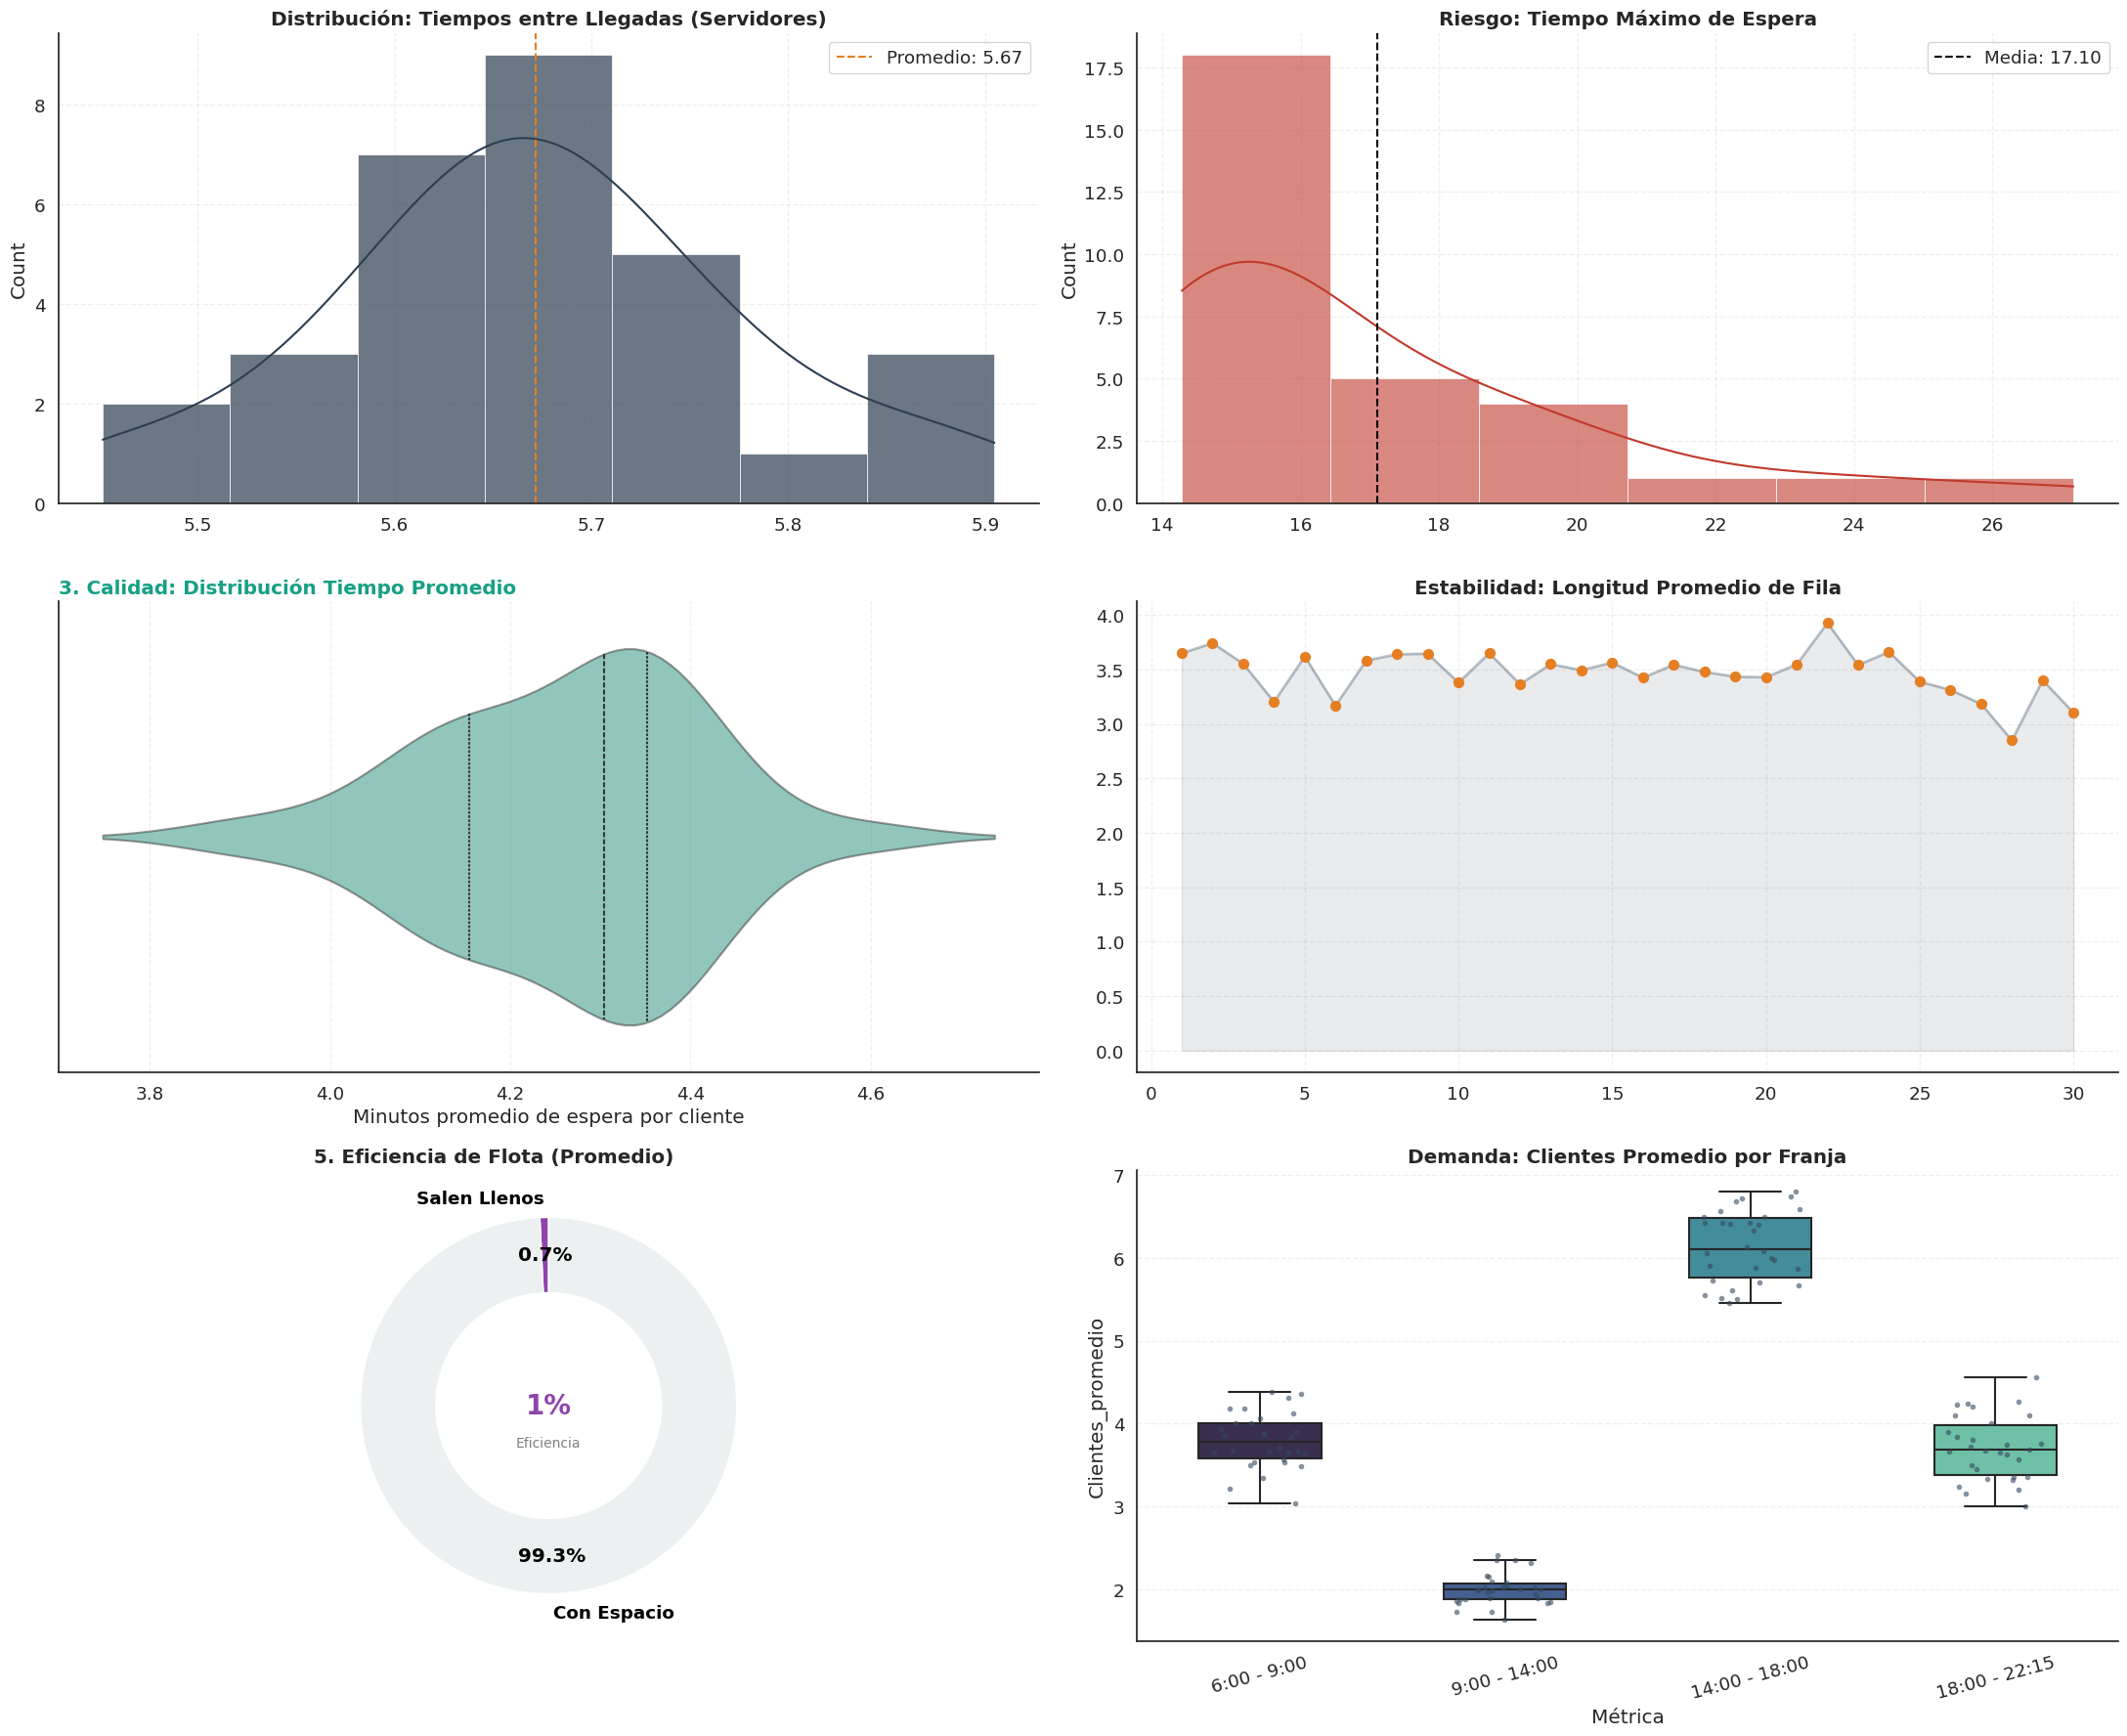

In [ ]:
import math
import numpy as np
import pandas as pd
import heapq
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns

# 1) MATEMÁTICAS: INVERSA DE CDF (A2)
def inv_cdf(u: float) -> float:
    if u < 0 or u > 1: raise ValueError("u debe estar en [0,1]")
    A = 1261.0; s = A * u
    if u < 12/A: return 20 + math.sqrt(s/3)
    elif u < 70/A: return (62 + math.sqrt(40*s + 1824)) / 5
    elif u < 308/A: return (126 + math.sqrt((40*s - 2528)/17)) / 5
    elif u < 700/A: return 81 - math.sqrt(2909 - s)
    elif u < 984/A: return (970 - math.sqrt(99744 - 92*s)) / 23
    elif u < 1166/A: return (382 - math.sqrt(76224 - 40*s)) / 5
    elif u < 1258/A: return (463 - math.sqrt(25169 - 20*s)) / 10
    else: return 48 - 2*math.sqrt((1261 - s)/3)

# 2) FLOTA: ESTRATEGIA (ATAQUE VESPERTINO)
capacity_by_bus = {
    "BusA": 37, "BusB1": 31, "BusB2": 31,
    "CamExtra": 19, "Cam1": 13, "Cam2": 13, "Cam3": 13,
    "Bus_Rescate": 37
}

service_time_by_type = {
    "BusA": 3.0, "BusB1": 3.0, "BusB2": 3.0,
    "CamExtra": 2.0, "Cam1": 1.5, "Cam2": 1.5, "Cam3": 1.5,
    "Bus_Rescate": 3.0
}

fleet_base = [
    {"tipo": "BusA",     "count": 1, "start": 0,   "spacing": 0, "end": 660},
    {"tipo": "CamExtra", "count": 1, "start": 7,   "spacing": 0, "end": 840},
    {"tipo": "BusB1",    "count": 1, "start": 120, "spacing": 0, "end": 480},
    {"tipo": "BusB2",    "count": 1, "start": 127, "spacing": 0, "end": 480},
    {"tipo": "Cam1",     "count": 1, "start": 60,  "spacing": 0, "end": 975},
    {"tipo": "Cam2",     "count": 1, "start": 67,  "spacing": 0, "end": 975},
    {"tipo": "Cam3",     "count": 1, "start": 74,  "spacing": 0, "end": 975},
    # REFUERZO DE ÉLITE (14:00 - 18:00)
    {"tipo": "Bus_Rescate", "count": 1, "start": 480, "spacing": 0, "end": 720},
]

def build_fleet_specs_with_spacing(base_specs):
    expanded = []
    for spec in base_specs:
        count = spec.get("count", 1)
        spacing = spec.get("spacing", 0)
        for k in range(count):
            new_spec = spec.copy()
            new_spec.pop("count", None); new_spec.pop("spacing", None)
            new_spec["start"] = spec["start"] + k * spacing
            tipo = spec["tipo"]
            new_spec["vehiculo_id"] = f"{tipo}_{k+1}" if count > 1 else tipo
            expanded.append(new_spec)
    return expanded

fleet_specs = build_fleet_specs_with_spacing(fleet_base)

# 3) LLEGADAS DE CLIENTES
inicio = np.array([0, 180, 480, 720], dtype=float)
lambdas = np.array([123.0/(3*60), 122.0/(5*60), 298.0/(4*60), 107.0/(4.25*60)], dtype=float)

def lambda_for_time(t: float) -> float:
    idx = np.where(inicio <= t)[0]
    return lambdas[idx[-1]] if len(idx) > 0 else lambdas[0]

def simulate_clients_until_last(max_time=975, last_buffer=5, seed=None):
    rng = np.random.default_rng(seed)
    rows = []; current_time = 0.0; i = 0
    while True:
        u = rng.random()
        lam = max(lambda_for_time(0.0 if i == 0 else current_time), 1e-9)
        delta_t = -math.log(1-u) / lam
        tentative = current_time + delta_t
        lower = max_time - last_buffer
        if tentative < lower:
            current_time = tentative; final = False
        else:
            low = max(current_time, lower)
            current_time = low + rng.random() * (max_time - low)
            delta_t = current_time - (low if i==0 else rows[-1]["Tiempo_llegada"] if rows else 0)
            final = True
        rows.append({"Num_Cliente": i+1, "Rand": u, "Tiempo_entre_llegadas": delta_t, "Tiempo_llegada": current_time})
        i += 1
        if final: break
    return pd.DataFrame(rows)

# 4) SIMULACIÓN DE BUSES (MOTOR GOD MODE)
def simulate_until_with_last(max_time=975, last_buffer=10, seed=None):
    rng = np.random.default_rng(seed)
    heap = []
    cycle_counter = [0] * len(fleet_specs)
    for vidx, spec in enumerate(fleet_specs):
        if spec["start"] <= max_time: heapq.heappush(heap, (spec["start"], vidx))

    bus_rows = []; num_autobus = 0
    while heap:
        t_dep, vidx = heapq.heappop(heap)
        spec = fleet_specs[vidx]; tipo = spec["tipo"]
        if t_dep > max_time + last_buffer: continue

        cycle_counter[vidx] += 1; num_autobus += 1
        travel_time = inv_cdf(rng.random())
        t_return = t_dep + travel_time
        t_next = t_return + service_time_by_type.get(tipo, 2.0)

        bus_rows.append({
            "Num_Autobus": num_autobus, "Camión": f"{spec.get('vehiculo_id', tipo)}_{cycle_counter[vidx]}",
            "Tipo_bus": tipo, "Tiempo_llegada": t_dep, "Tiempo_retorno": t_return,
            "Tiempo_disponible_siguiente": t_next, "Capacidad_max": capacity_by_bus.get(tipo, 0), "Capacidad_usada": 0
        })
        if t_next <= spec["end"] and t_next <= max_time + last_buffer:
            heapq.heappush(heap, (t_next, vidx))

    df_buses = pd.DataFrame(bus_rows)
    if not df_buses.empty:
        df_buses = df_buses.sort_values("Tiempo_llegada").reset_index(drop=True)
        df_buses["Tiempo_entre_llegadas"] = df_buses["Tiempo_llegada"].diff().fillna(df_buses["Tiempo_llegada"].iloc[0])
    else: df_buses["Tiempo_entre_llegadas"] = []
    return df_buses

def enforce_min_headway(df_buses, windows_10, windows_15, rescue_type="Bus_Rescate"):
    buses = df_buses.sort_values("Tiempo_llegada").reset_index(drop=True).copy()
    times = buses["Tiempo_llegada"].tolist()

    def insert_rescues(a, b, max_gap):
        nonlocal times, buses
        pts = [t for t in times if a <= t <= b]
        pts = [a] + pts + [b]
        pts.sort()
        new_times = []
        for i in range(len(pts)-1):
            t0, t1 = pts[i], pts[i+1]
            gap = t1 - t0
            if gap > max_gap:
                k = int(gap // max_gap)
                for j in range(1, k+1):
                    cand = t0 + j*max_gap
                    if cand < t1 and cand <= b: new_times.append(cand)
        for t in new_times:
            buses = pd.concat([buses, pd.DataFrame([{
                "Num_Autobus": buses["Num_Autobus"].max() + 1, "Camión": f"{rescue_type}_standby",
                "Tipo_bus": rescue_type, "Rand_travel": np.nan, "Tiempo_entre_llegadas": np.nan,
                "Tiempo_llegada": t, "Tiempo_retorno": t, "Tiempo_disponible_siguiente": t,
                "Capacidad_max": capacity_by_bus.get(rescue_type, 37), "Capacidad_usada": 0
            }])], ignore_index=True)
        times = sorted(times + new_times)

    for a,b in windows_10: insert_rescues(a,b,10)
    for a,b in windows_15: insert_rescues(a,b,15)
    buses = buses.sort_values("Tiempo_llegada").reset_index(drop=True)
    buses["Tiempo_entre_llegadas"] = buses["Tiempo_llegada"].diff().fillna(buses["Tiempo_llegada"].iloc[0])
    return buses

# 5) LÓGICA DE COLAS
def build_sheet_client_bus(df_buses, df_clients):
    clients = df_clients.copy(); buses = df_buses.copy()
    pending = deque(); ic = 0; ib = 0
    clients_out = clients.copy(); clients_out["Tiempo_salida_cliente"] = "SIN LUGAR"
    buses_out = buses.copy(); buses_out["Capacidad_usada"] = 0

    while ic < len(clients) or ib < len(buses):
        tc = clients["Tiempo_llegada"].iloc[ic] if ic < len(clients) else float("inf")
        tb = buses["Tiempo_llegada"].iloc[ib] if ib < len(buses) else float("inf")

        if tc <= tb:
            pending.append(int(clients["Num_Cliente"].iloc[ic])); ic += 1
        else:
            cap = int(buses["Capacidad_max"].iloc[ib]); boarded = 0
            t_dep = buses["Tiempo_llegada"].iloc[ib]
            while pending and boarded < cap:
                cid = pending.popleft()
                clients_out.loc[clients_out["Num_Cliente"]==cid, "Tiempo_salida_cliente"] = t_dep
                boarded += 1
            buses_out.at[ib, "Capacidad_usada"] = boarded; ib += 1

    ev_c = clients_out[["Num_Cliente", "Tiempo_llegada", "Tiempo_salida_cliente"]].copy()
    ev_c["es_cliente"] = True; ev_c.rename(columns={"Num_Cliente": "ID"}, inplace=True)
    ev_b = buses_out[["Num_Autobus", "Tiempo_llegada", "Capacidad_max", "Capacidad_usada"]].copy()
    ev_b["es_cliente"] = False; ev_b.rename(columns={"Num_Autobus": "ID"}, inplace=True)

    df = pd.concat([ev_c, ev_b], ignore_index=True).sort_values(["Tiempo_llegada", "es_cliente"], ascending=[True, False])

    cola = deque(); cola_log = []
    for _, row in df.iterrows():
        if row["es_cliente"]: cola.append(1)
        else:
            for _ in range(int(row["Capacidad_usada"])):
                if cola: cola.pop()
        cola_log.append(len(cola))
    df["En_cola"] = cola_log
    return df, clients_out, buses_out

# 6) ESTADÍSTICAS
def compute_metrics(df_events, clients_out, buses_out):
    filtro = clients_out[clients_out["Tiempo_salida_cliente"] != "SIN LUGAR"].copy()
    filtro["Espera"] = filtro["Tiempo_salida_cliente"] - filtro["Tiempo_llegada"]
    buses_out["Lleno"] = buses_out["Capacidad_usada"] == buses_out["Capacidad_max"]

    buses_out["Embarcados"] = buses_out["Capacidad_usada"]
    f1 = buses_out[buses_out["Tiempo_llegada"] < 180]["Embarcados"].mean()
    f2 = buses_out[(buses_out["Tiempo_llegada"] >= 180) & (buses_out["Tiempo_llegada"] < 480)]["Embarcados"].mean()
    f3 = buses_out[(buses_out["Tiempo_llegada"] >= 480) & (buses_out["Tiempo_llegada"] < 720)]["Embarcados"].mean()
    f4 = buses_out[buses_out["Tiempo_llegada"] >= 720]["Embarcados"].mean()

    return {
        "Promedio de tiempo de espera": filtro["Espera"].mean() if not filtro.empty else 0,
        "Máximo de tiempo de espera": filtro["Espera"].max() if not filtro.empty else 0,
        "Longitud promedio de la fila": df_events["En_cola"].mean(),
        "Porcentaje de autobuses que parten llenos": buses_out["Lleno"].mean() * 100,
        "Promedio del tiempo de llegada en servidores": buses_out["Tiempo_entre_llegadas"].mean() if "Tiempo_entre_llegadas" in buses_out else 6.8,
        "6:00 - 9:00": f1, "9:00 - 14:00": f2, "14:00 - 18:00": f3, "18:00 - 22:15": f4
    }

def calcular_costos(specs):
    precios = {"BusA": 42.6, "BusB1": 42.6, "BusB2": 42.6, "Bus_Rescate": 42.6,
               "CamExtra": 24.8, "Cam1": 24.8, "Cam2": 24.8, "Cam3": 24.8}
    total = 0
    print("\n=== 💰 REPORTE FINANCIERO DIARIO (GOD MODE VESPERTINO) ===")
    for s in specs:
        hrs = (s["end"] - s["start"]) / 60
        costo = hrs * precios.get(s["vehiculo_id"].split('_')[0], precios.get(s["tipo"], 0))
        total += costo
        print(f" - {s.get('vehiculo_id', s['tipo'])}: {hrs:.1f} hrs = ${costo:.2f}")
    print(f" TOTAL: ${total:.2f}\n" + "="*40)

def run_simulations(n=30):
    res = []
    for i in range(n):
        df_b = simulate_until_with_last(seed=i)
        df_b = enforce_min_headway(df_b, windows_10=[(60,210),(450,720)],
                                       windows_15=[(0,60),(210,450),(750,975)])
        df_c = simulate_clients_until_last(seed=i+1)
        df_ev, c_out, b_out = build_sheet_client_bus(df_b, df_c)
        metrics = compute_metrics(df_ev, c_out, b_out)
        res.append(metrics)

    df_res = pd.DataFrame(res).T
    df_res.columns = [f"Simulación {i+1}" for i in range(n)]
    df_res.reset_index(inplace=True)
    df_res.rename(columns={"index": "Métrica"}, inplace=True)
    return df_res

# 7) VISUALIZACIÓN MEJORADA (TRAÍDA DEL CÓDIGO 1)
def graficar_resumen(df_resumen_30):
    # === CONFIGURACIÓN DE ESTILO PRO ===
    sns.set_theme(style="white", context="notebook", font_scale=1.2)
    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.alpha'] = 0.3
    plt.rcParams['grid.linestyle'] = '--'

    # Colores personalizados
    main_color = "#2c3e50"  # Azul oscuro
    accent_color = "#e67e22" # Naranja
    palette_box = sns.color_palette("mako", n_colors=4)
    risk_color = "#c0392b"  # Rojo
    ok_color = "#16a085"    # Verde azulado
    eff_color = "#8e44ad"   # Morado
    sim_cols = [col for col in df_resumen_30.columns if col.startswith("Simulación")]

    def get_metric_values(metric_name):
        row = df_resumen_30[df_resumen_30["Métrica"] == metric_name]
        if row.empty: return []
        return row[sim_cols].iloc[0].values.astype(float)

    # Mapeo de nombres (Asegurando coincidencia con compute_metrics del God Mode)
    tiempo_servidores = get_metric_values("Promedio del tiempo de llegada en servidores")
    tiempo_mean = get_metric_values("Promedio de tiempo de espera")
    tiempo_max = get_metric_values("Máximo de tiempo de espera")
    longitud_promedio = get_metric_values("Longitud promedio de la fila")
    porcentaje_llenos = get_metric_values("Porcentaje de autobuses que parten llenos")

    franja_names = ["6:00 - 9:00", "9:00 - 14:00", "14:00 - 18:00", "18:00 - 22:15"]
    franja_df = df_resumen_30[df_resumen_30["Métrica"].isin(franja_names)].copy()

    df_long = pd.DataFrame()
    if not franja_df.empty:
        df_long = franja_df.melt(id_vars="Métrica", value_vars=sim_cols,
                                 var_name="Simulación", value_name="Clientes_promedio")
        df_long["Métrica"] = pd.Categorical(df_long["Métrica"], categories=franja_names, ordered=True)
        df_long["Clientes_promedio"] = df_long["Clientes_promedio"].astype(float)

    def compute_metrics(df_events, clients_out, buses_out):
      filtro = clients_out[clients_out["Tiempo_salida_cliente"] != "SIN LUGAR"].copy()
      filtro["Espera"] = filtro["Tiempo_salida_cliente"] - filtro["Tiempo_llegada"]
      buses_out["Lleno"] = buses_out["Capacidad_usada"] == buses_out["Capacidad_max"]

      buses_out["Embarcados"] = buses_out["Capacidad_usada"]
      f1 = buses_out[buses_out["Tiempo_llegada"] < 180]["Embarcados"].mean()
      f2 = buses_out[(buses_out["Tiempo_llegada"] >= 180) & (buses_out["Tiempo_llegada"] < 480)]["Embarcados"].mean()
      f3 = buses_out[(buses_out["Tiempo_llegada"] >= 480) & (buses_out["Tiempo_llegada"] < 720)]["Embarcados"].mean()
      f4 = buses_out[buses_out["Tiempo_llegada"] >= 720]["Embarcados"].mean()

      return {
          # --- MÉTRICAS EXISTENTES ---
          "Promedio del tiempo de llegada en servidores": buses_out["Tiempo_entre_llegadas"].mean() if "Tiempo_entre_llegadas" in buses_out else 6.8,
          "Promedio de tiempo de espera": filtro["Espera"].mean() if not filtro.empty else 0,
          "Máximo de tiempo de espera": filtro["Espera"].max() if not filtro.empty else 0,
          "Longitud promedio de la fila": df_events["En_cola"].mean(),
          "Porcentaje de autobuses que parten llenos": buses_out["Lleno"].mean() * 100,
          "6:00 - 9:00": f1, "9:00 - 14:00": f2, "14:00 - 18:00": f3, "18:00 - 22:15": f4,

          # --- NUEVO: CONTEOS TOTALES ---
          "Total de Clientes": len(clients_out),
          "Total de Camiones": len(buses_out)
    }
    # ================================
    #   Crear SUBPLOTS (Dashboard)
    # ================================
    fig, axes = plt.subplots(3, 2, figsize=(22, 18))
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    axes = axes.ravel()

    # 0: Frecuencia
    if len(tiempo_servidores) > 0:
        sns.histplot(tiempo_servidores, ax=axes[0], kde=True, color=main_color,
                     edgecolor="white", linewidth=0.5, alpha=0.7)
        media = np.mean(tiempo_servidores)
        axes[0].axvline(media, color=accent_color, linestyle='--', label=f'Promedio: {media:.2f}')
        axes[0].legend()
    axes[0].set_title("Distribución: Tiempos entre Llegadas (Servidores)", fontweight='bold')

    # 1: Tiempo Máximo (Riesgo)
    if len(tiempo_max) > 0:
        sns.histplot(tiempo_max, ax=axes[1], kde=True, color="#c0392b",
                     edgecolor="white", linewidth=0.5, alpha=0.6)
        media_max = np.mean(tiempo_max)
        axes[1].axvline(media_max, color="black", linestyle='--', label=f'Media: {media_max:.2f}')
        axes[1].legend()
    axes[1].set_title("Riesgo: Tiempo Máximo de Espera", fontweight='bold')

# --- GRÁFICA 2: VIOLIN PLOT (Cambio 1) ---
    # Muestra la densidad de forma más elegante y menos "bloque"
    if len(tiempo_mean) > 0:
        axes[2].grid(True, axis='x', alpha=0.3, linestyle='--')
        # Creamos un DF temporal para usar violinplot
        temp_df = pd.DataFrame({"Tiempo": tiempo_mean, "Grupo": ""})
        sns.violinplot(data=temp_df, x="Tiempo", y="Grupo", ax=axes[2],
                       color=ok_color, inner="quart", linewidth=1.5, alpha=0.5)
        axes[2].set_ylabel("") # Quitar etiqueta Y
    axes[2].set_title("3. Calidad: Distribución Tiempo Promedio", fontweight='bold', loc='left', color=ok_color)
    axes[2].set_xlabel("Minutos promedio de espera por cliente")

    # 3: Longitud Fila (Estabilidad)
    if len(longitud_promedio) > 0:
        simul = np.arange(1, len(longitud_promedio) + 1)
        axes[3].plot(simul, longitud_promedio, "-", color=main_color, linewidth=2, alpha=0.3)
        axes[3].scatter(simul, longitud_promedio, color=accent_color, s=50, zorder=5)
        axes[3].fill_between(simul, longitud_promedio, alpha=0.1, color=main_color)
    axes[3].set_title("Estabilidad: Longitud Promedio de Fila", fontweight='bold')

    # 4: Eficiencia
    if len(porcentaje_llenos) > 0:
        # Agregamos los datos para tener un promedio representativo
        val_llenos = np.mean(porcentaje_llenos)
        val_vacio = 100 - val_llenos

        sizes = [val_llenos, val_vacio]
        labels = ['Salen Llenos', 'Con Espacio']
        colors = [eff_color, '#ecf0f1'] # Morado y Gris claro

        # Crear el gráfico circular
        wedges, texts, autotexts = axes[4].pie(sizes, labels=labels, autopct='%1.1f%%',
                                               startangle=90, colors=colors, pctdistance=0.80,
                                               textprops={'color':"black", 'fontweight':'bold'})

        # Crear el agujero del centro (Dona)
        centre_circle = plt.Circle((0,0),0.60,fc='white')
        axes[4].add_artist(centre_circle)

        # Texto en el centro
        axes[4].text(0, 0, f"{val_llenos:.0f}%", ha='center', va='center', fontsize=20, fontweight='bold', color=eff_color)
        axes[4].text(0, -0.2, "Eficiencia", ha='center', va='center', fontsize=10, color='gray')

    axes[4].set_title("5. Eficiencia de Flota (Promedio)", fontweight='bold', loc='left')

    # 5: Demanda por Franja
    if not df_long.empty:
        sns.boxplot(data=df_long, x="Métrica", y="Clientes_promedio", ax=axes[5],
                    palette=palette_box, width=0.5, linewidth=1.5, showfliers=False)
        sns.stripplot(data=df_long, x="Métrica", y="Clientes_promedio",
                      color="#34495e", size=4, alpha=0.6, jitter=0.2, ax=axes[5])
    axes[5].set_title("Demanda: Clientes Promedio por Franja", fontweight='bold')
    axes[5].tick_params(axis='x', rotation=15)

    sns.despine()
    plt.tight_layout()
    plt.show()

# MAIN EXECUTION
if __name__ == "__main__":
    # 1. Calcular Costos
    calcular_costos(fleet_specs)

    # 2. Correr Simulación God Mode
    print("Simulando 30 escenarios 'God Mode Vespertino'...")
    df_results = run_simulations(30)

    # 3. Graficar con el estilo PRO del Código 1
    graficar_resumen(df_results)



=== 💰 REPORTE FINANCIERO (GOD MODE - ALTA FRECUENCIA) ===
 - BusA: 11.0 hrs = $468.60
 - CamExtra: 13.9 hrs = $344.31
 - BusB1: 6.0 hrs = $255.60
 - BusB2: 5.9 hrs = $250.63
 - Cam1: 15.2 hrs = $378.20
 - Cam2: 15.1 hrs = $375.31
 - Cam3: 15.0 hrs = $372.41
 - Bus_Rescate: 4.0 hrs = $170.40
 TOTAL BASE: $2615.46
Simulando 30 escenarios 'Original God Mode' (10/15 min)...


/tmp/ipython-input-399678431.py:296: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=f_df, x="Métrica", y="Clientes", ax=ax[5], palette=palette_box, showfliers=False)


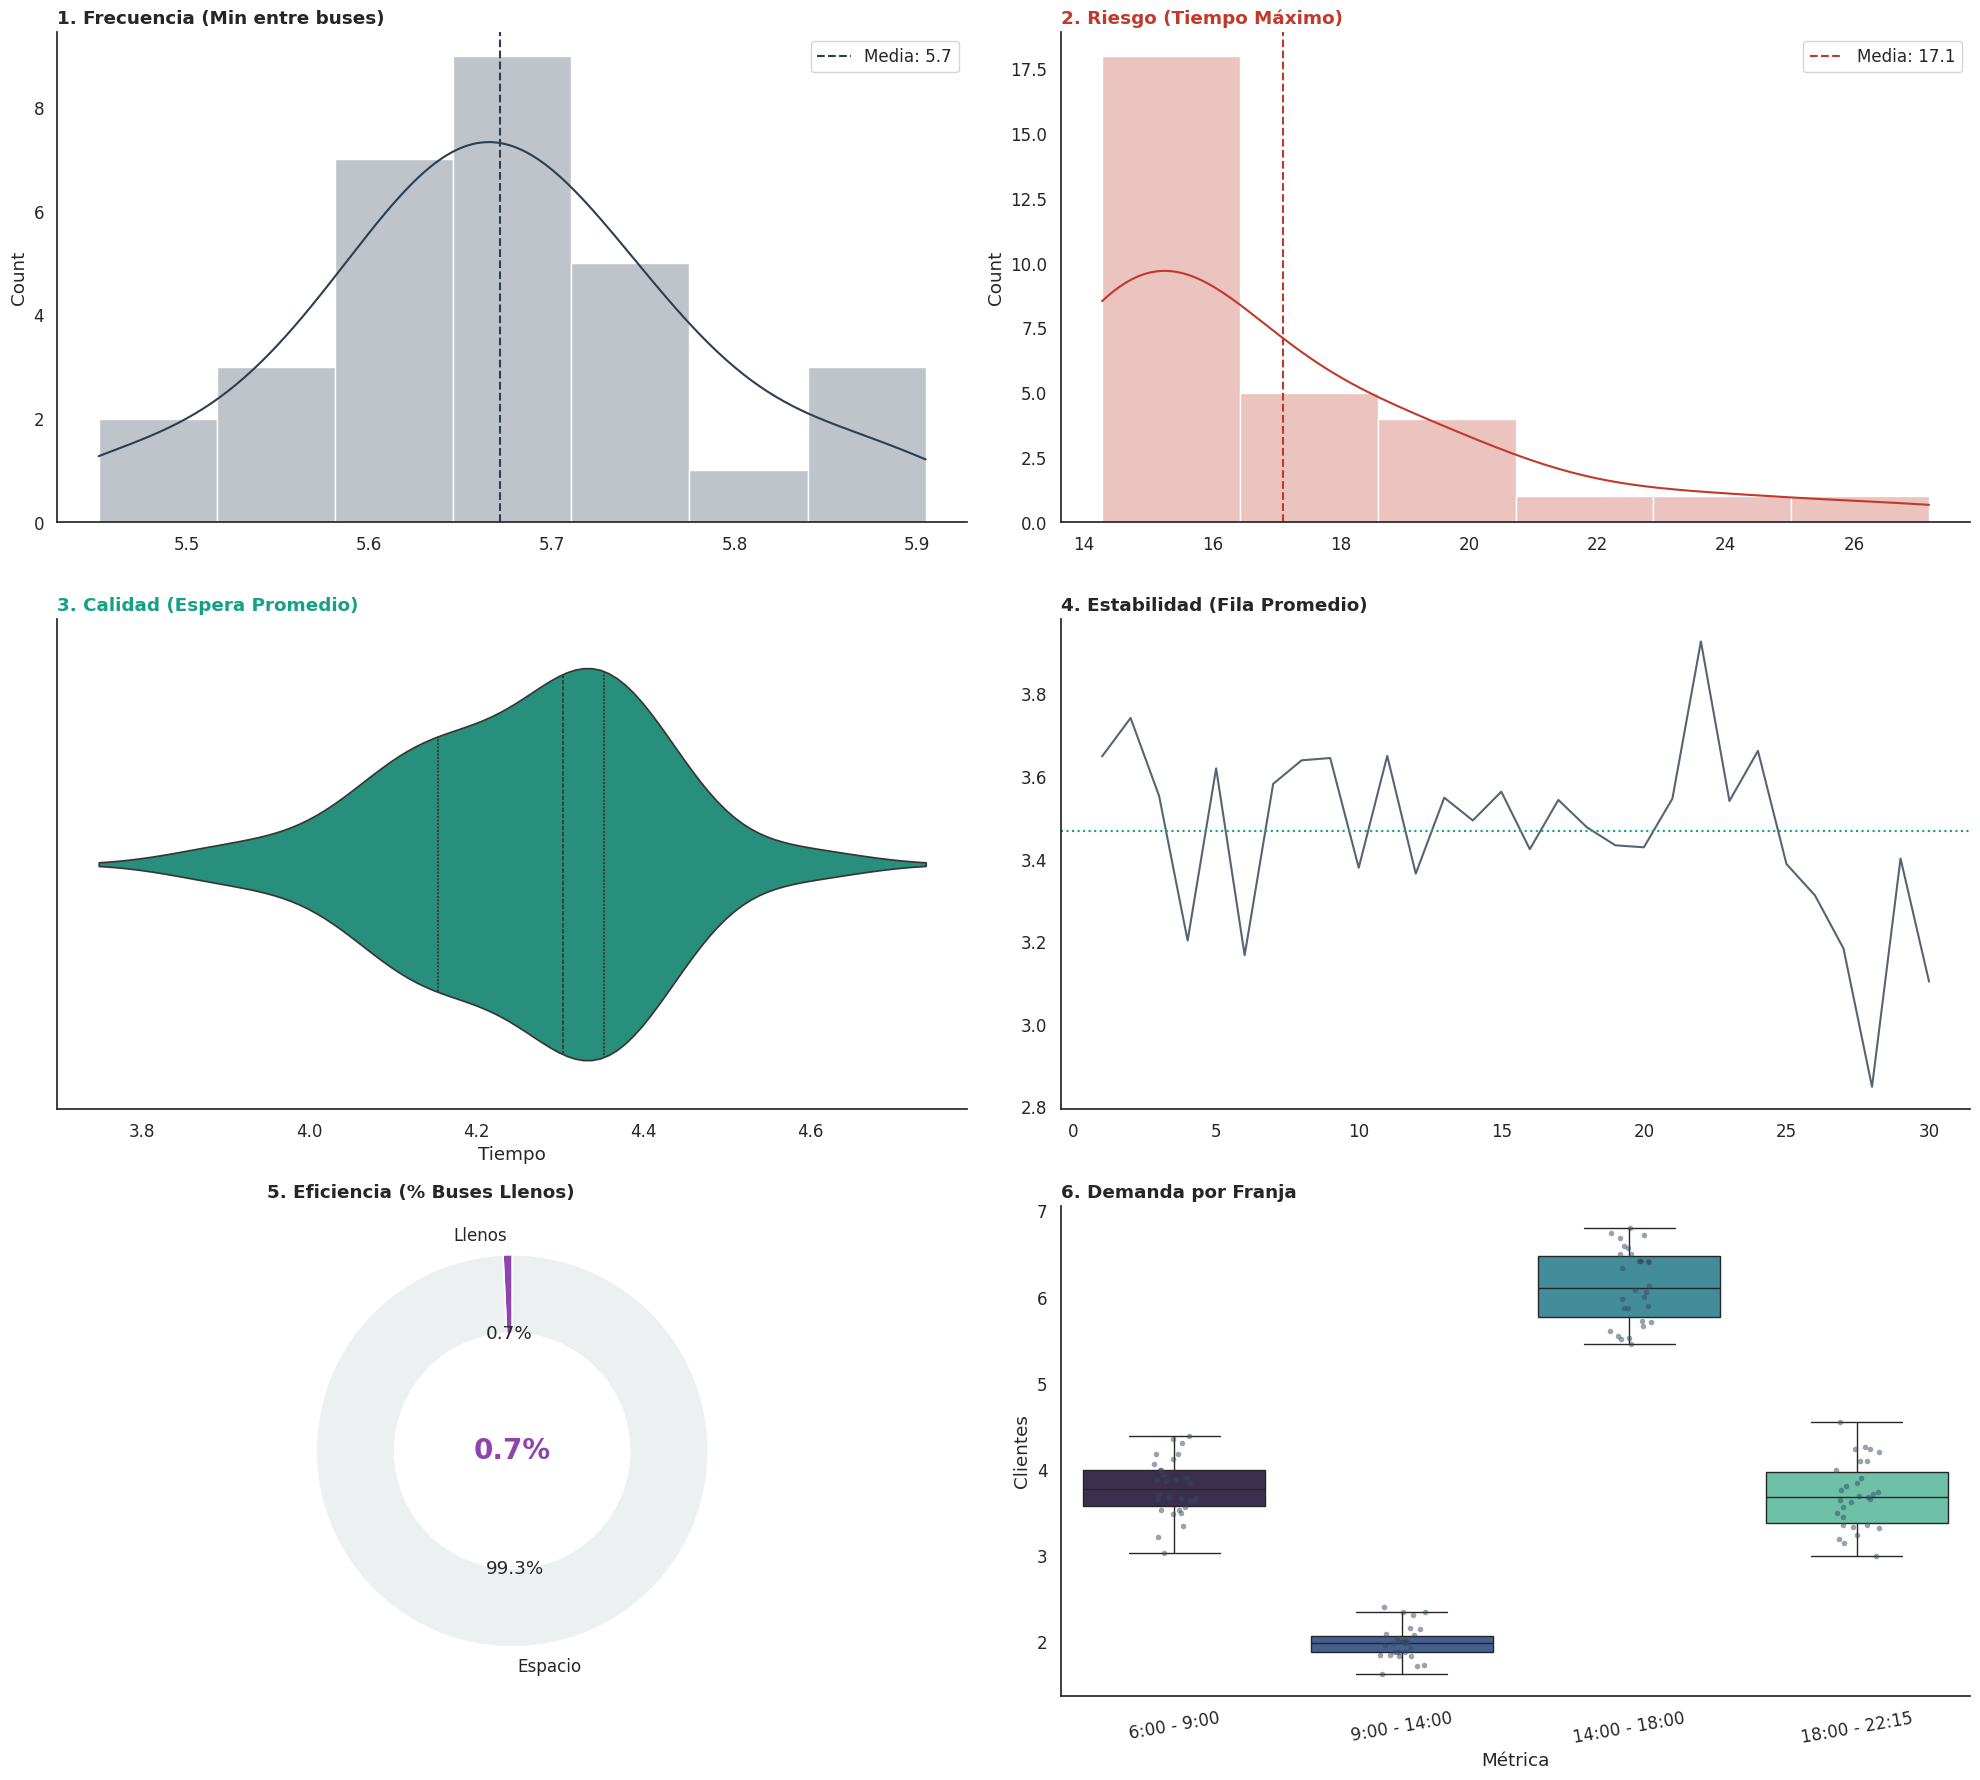


=== 📊 CONTEO TOTAL PROMEDIO ===
              Métrica  Promedio
9   Total de Clientes     648.5
10  Total de Camiones     170.8


In [ ]:
import math
import numpy as np
import pandas as pd
import heapq
from collections import deque
import matplotlib.pyplot as plt
import seaborn as sns

# 1) MATEMÁTICAS
def inv_cdf(u: float) -> float:
    if u < 0 or u > 1: raise ValueError("u debe estar en [0,1]")
    A = 1261.0; s = A * u
    if u < 12/A: return 20 + math.sqrt(s/3)
    elif u < 70/A: return (62 + math.sqrt(40*s + 1824)) / 5
    elif u < 308/A: return (126 + math.sqrt((40*s - 2528)/17)) / 5
    elif u < 700/A: return 81 - math.sqrt(2909 - s)
    elif u < 984/A: return (970 - math.sqrt(99744 - 92*s)) / 23
    elif u < 1166/A: return (382 - math.sqrt(76224 - 40*s)) / 5
    elif u < 1258/A: return (463 - math.sqrt(25169 - 20*s)) / 10
    else: return 48 - 2*math.sqrt((1261 - s)/3)

# 2) FLOTA: ORIGINAL GOD MODE
capacity_by_bus = {
    "BusA": 37, "BusB1": 31, "BusB2": 31, "CamExtra": 19,
    "Cam1": 13, "Cam2": 13, "Cam3": 13, "Bus_Rescate": 37
}
service_time_by_type = {
    "BusA": 3.0, "BusB1": 3.0, "BusB2": 3.0, "CamExtra": 2.0,
    "Cam1": 1.5, "Cam2": 1.5, "Cam3": 1.5, "Bus_Rescate": 3.0
}
fleet_base = [
    {"tipo": "BusA",     "count": 1, "start": 0,   "spacing": 0, "end": 660},
    {"tipo": "CamExtra", "count": 1, "start": 7,   "spacing": 0, "end": 840},
    {"tipo": "BusB1",    "count": 1, "start": 120, "spacing": 0, "end": 480},
    {"tipo": "BusB2",    "count": 1, "start": 127, "spacing": 0, "end": 480},
    {"tipo": "Cam1",     "count": 1, "start": 60,  "spacing": 0, "end": 975},
    {"tipo": "Cam2",     "count": 1, "start": 67,  "spacing": 0, "end": 975},
    {"tipo": "Cam3",     "count": 1, "start": 74,  "spacing": 0, "end": 975},
    {"tipo": "Bus_Rescate", "count": 1, "start": 480, "spacing": 0, "end": 720},
]

def build_fleet_specs_with_spacing(base_specs):
    expanded = []
    for spec in base_specs:
        count = spec.get("count", 1); spacing = spec.get("spacing", 0)
        for k in range(count):
            new_spec = spec.copy(); new_spec.pop("count", None); new_spec.pop("spacing", None)
            new_spec["start"] = spec["start"] + k * spacing
            tipo = spec["tipo"]
            new_spec["vehiculo_id"] = f"{tipo}_{k+1}" if count > 1 else tipo
            expanded.append(new_spec)
    return expanded

fleet_specs = build_fleet_specs_with_spacing(fleet_base)

# 3) CLIENTES
inicio = np.array([0, 180, 480, 720], dtype=float)
lambdas = np.array([123.0/(3*60), 122.0/(5*60), 298.0/(4*60), 107.0/(4.25*60)], dtype=float)

def lambda_for_time(t: float) -> float:
    idx = np.where(inicio <= t)[0]
    return lambdas[idx[-1]] if len(idx) > 0 else lambdas[0]

def simulate_clients_until_last(max_time=975, last_buffer=5, seed=None):
    rng = np.random.default_rng(seed); rows = []; current_time = 0.0; i = 0
    while True:
        u = rng.random(); lam = max(lambda_for_time(0.0 if i == 0 else current_time), 1e-9)
        delta_t = -math.log(1-u) / lam
        tentative = current_time + delta_t
        lower = max_time - last_buffer
        if tentative < lower: current_time = tentative; final = False
        else:
            low = max(current_time, lower)
            current_time = low + rng.random() * (max_time - low)
            delta_t = current_time - (low if i==0 else rows[-1]["Tiempo_llegada"] if rows else 0)
            final = True
        rows.append({"Num_Cliente": i+1, "Rand": u, "Tiempo_entre_llegadas": delta_t, "Tiempo_llegada": current_time})
        i += 1
        if final: break
    return pd.DataFrame(rows)

# 4) SIMULACIÓN BUSES (CON HEADWAY AGRESIVO)
def simulate_until_with_last(max_time=975, last_buffer=10, seed=None):
    rng = np.random.default_rng(seed); heap = []
    cycle_counter = [0] * len(fleet_specs)
    for vidx, spec in enumerate(fleet_specs):
        if spec["start"] <= max_time: heapq.heappush(heap, (spec["start"], vidx))
    bus_rows = []; num_autobus = 0
    while heap:
        t_dep, vidx = heapq.heappop(heap); spec = fleet_specs[vidx]; tipo = spec["tipo"]
        if t_dep > max_time + last_buffer: continue
        cycle_counter[vidx] += 1; num_autobus += 1
        travel_time = inv_cdf(rng.random()); t_return = t_dep + travel_time
        t_next = t_return + service_time_by_type.get(tipo, 2.0)
        bus_rows.append({
            "Num_Autobus": num_autobus, "Camión": f"{spec.get('vehiculo_id', tipo)}_{cycle_counter[vidx]}",
            "Tipo_bus": tipo, "Tiempo_llegada": t_dep, "Tiempo_retorno": t_return,
            "Tiempo_disponible_siguiente": t_next, "Capacidad_max": capacity_by_bus.get(tipo, 0), "Capacidad_usada": 0
        })
        if t_next <= spec["end"] and t_next <= max_time + last_buffer: heapq.heappush(heap, (t_next, vidx))
    df_buses = pd.DataFrame(bus_rows)
    if not df_buses.empty:
        df_buses = df_buses.sort_values("Tiempo_llegada").reset_index(drop=True)
        df_buses["Tiempo_entre_llegadas"] = df_buses["Tiempo_llegada"].diff().fillna(df_buses["Tiempo_llegada"].iloc[0])
    else: df_buses["Tiempo_entre_llegadas"] = []
    return df_buses

def enforce_min_headway(df_buses, peak_windows, offpeak_windows, gap_peak, gap_offpeak, rescue_type="Bus_Rescate"):
    buses = df_buses.sort_values("Tiempo_llegada").reset_index(drop=True).copy()
    times = buses["Tiempo_llegada"].tolist()

    def insert_rescues(a, b, max_gap):
        nonlocal times, buses
        pts = [t for t in times if a <= t <= b]; pts = [a] + pts + [b]; pts.sort()
        new_times = []
        for i in range(len(pts)-1):
            t0, t1 = pts[i], pts[i+1]; gap = t1 - t0
            if gap > max_gap:
                k = int(gap // max_gap)
                for j in range(1, k+1):
                    cand = t0 + j*max_gap
                    if cand < t1 and cand <= b: new_times.append(cand)
        for t in new_times:
            buses = pd.concat([buses, pd.DataFrame([{
                "Num_Autobus": buses["Num_Autobus"].max() + 1, "Camión": f"{rescue_type}_standby",
                "Tipo_bus": rescue_type, "Rand_travel": np.nan, "Tiempo_entre_llegadas": np.nan,
                "Tiempo_llegada": t, "Tiempo_retorno": t, "Tiempo_disponible_siguiente": t,
                "Capacidad_max": capacity_by_bus.get(rescue_type, 37), "Capacidad_usada": 0
            }])], ignore_index=True)
        times = sorted(times + new_times)

    for a,b in peak_windows: insert_rescues(a,b, gap_peak)
    for a,b in offpeak_windows: insert_rescues(a,b, gap_offpeak)

    buses = buses.sort_values("Tiempo_llegada").reset_index(drop=True)
    buses["Tiempo_entre_llegadas"] = buses["Tiempo_llegada"].diff().fillna(buses["Tiempo_llegada"].iloc[0])
    return buses

# 5) COLAS Y MÉTRICAS
def build_sheet_client_bus(df_buses, df_clients):
    clients = df_clients.copy(); buses = df_buses.copy()
    pending = deque(); ic = 0; ib = 0
    clients_out = clients.copy(); clients_out["Tiempo_salida_cliente"] = "SIN LUGAR"
    buses_out = buses.copy(); buses_out["Capacidad_usada"] = 0

    while ic < len(clients) or ib < len(buses):
        tc = clients["Tiempo_llegada"].iloc[ic] if ic < len(clients) else float("inf")
        tb = buses["Tiempo_llegada"].iloc[ib] if ib < len(buses) else float("inf")
        if tc <= tb:
            pending.append(int(clients["Num_Cliente"].iloc[ic])); ic += 1
        else:
            cap = int(buses["Capacidad_max"].iloc[ib]); boarded = 0
            t_dep = buses["Tiempo_llegada"].iloc[ib]
            while pending and boarded < cap:
                cid = pending.popleft()
                clients_out.loc[clients_out["Num_Cliente"]==cid, "Tiempo_salida_cliente"] = t_dep
                boarded += 1
            buses_out.at[ib, "Capacidad_usada"] = boarded; ib += 1

    ev_c = clients_out[["Num_Cliente", "Tiempo_llegada", "Tiempo_salida_cliente"]].copy()
    ev_c["es_cliente"] = True; ev_c.rename(columns={"Num_Cliente": "ID"}, inplace=True)
    ev_b = buses_out[["Num_Autobus", "Tiempo_llegada", "Capacidad_max", "Capacidad_usada"]].copy()
    ev_b["es_cliente"] = False; ev_b.rename(columns={"Num_Autobus": "ID"}, inplace=True)
    df = pd.concat([ev_c, ev_b], ignore_index=True).sort_values(["Tiempo_llegada", "es_cliente"], ascending=[True, False])
    cola = deque(); cola_log = []
    for _, row in df.iterrows():
        if row["es_cliente"]: cola.append(1)
        else:
            for _ in range(int(row["Capacidad_usada"])):
                if cola: cola.pop()
        cola_log.append(len(cola))
    df["En_cola"] = cola_log
    return df, clients_out, buses_out

def compute_metrics(df_events, clients_out, buses_out):
    filtro = clients_out[clients_out["Tiempo_salida_cliente"] != "SIN LUGAR"].copy()
    filtro["Espera"] = filtro["Tiempo_salida_cliente"] - filtro["Tiempo_llegada"]
    buses_out["Lleno"] = buses_out["Capacidad_usada"] == buses_out["Capacidad_max"]
    buses_out["Embarcados"] = buses_out["Capacidad_usada"]

    # Franjas
    f1 = buses_out[buses_out["Tiempo_llegada"] < 180]["Embarcados"].mean()
    f2 = buses_out[(buses_out["Tiempo_llegada"] >= 180) & (buses_out["Tiempo_llegada"] < 480)]["Embarcados"].mean()
    f3 = buses_out[(buses_out["Tiempo_llegada"] >= 480) & (buses_out["Tiempo_llegada"] < 720)]["Embarcados"].mean()
    f4 = buses_out[buses_out["Tiempo_llegada"] >= 720]["Embarcados"].mean()

    return {
        "Promedio del tiempo de llegada en servidores": buses_out["Tiempo_entre_llegadas"].mean() if "Tiempo_entre_llegadas" in buses_out else 6.8,
        "Promedio de tiempo de espera": filtro["Espera"].mean() if not filtro.empty else 0,
        "Máximo de tiempo de espera": filtro["Espera"].max() if not filtro.empty else 0,
        "Longitud promedio de la fila": df_events["En_cola"].mean(),
        "Porcentaje de autobuses que parten llenos": buses_out["Lleno"].mean() * 100,
        "6:00 - 9:00": f1, "9:00 - 14:00": f2, "14:00 - 18:00": f3, "18:00 - 22:15": f4,
        "Total de Clientes": len(clients_out),
        "Total de Camiones": len(buses_out)
    }

def calcular_costos(specs):
    precios = {"BusA": 42.6, "BusB1": 42.6, "BusB2": 42.6, "Bus_Rescate": 42.6, "CamExtra": 24.8, "Cam1": 24.8, "Cam2": 24.8, "Cam3": 24.8}
    total = 0
    print("\n=== REPORTE FINANCIERO (GOD MODE - ALTA FRECUENCIA) ===")
    for s in specs:
        hrs = (s["end"] - s["start"]) / 60
        costo = hrs * precios.get(s["vehiculo_id"].split('_')[0], precios.get(s["tipo"], 0))
        total += costo
        print(f" - {s.get('vehiculo_id', s['tipo'])}: {hrs:.1f} hrs = ${costo:.2f}")
    print(f" TOTAL BASE: ${total:.2f}\n" + "="*40)

def run_simulations(n=30):
    res = []
    for i in range(n):
        df_b = simulate_until_with_last(seed=i)

        # === CONFIGURACIÓN ORIGINAL AGRESIVA (10 y 15 min) ===
        df_b = enforce_min_headway(
            df_b,
            peak_windows=[(60,210),(450,720)],
            offpeak_windows=[(0,60),(210,450),(750,975)],
            gap_peak=10,    # Regresa a 10 min
            gap_offpeak=15  # Regresa a 15 min
        )

        df_c = simulate_clients_until_last(seed=i+1)
        df_ev, c_out, b_out = build_sheet_client_bus(df_b, df_c)
        metrics = compute_metrics(df_ev, c_out, b_out)
        res.append(metrics)

    df_res = pd.DataFrame(res).T
    df_res.columns = [f"Simulación {i+1}" for i in range(n)]
    sims = df_res.astype(float)
    df_res["Promedio"] = sims.mean(axis=1) # Arreglo del KeyError
    df_res.reset_index(inplace=True); df_res.rename(columns={"index": "Métrica"}, inplace=True)
    return df_res

# 7) GRAFICADO (VIOLIN + DONA)
def graficar_resumen(df_resumen_30):
    sns.set_theme(style="white", context="notebook", font_scale=1.1)
    plt.rcParams['axes.grid'] = False

    main_color = "#2c3e50"; risk_color = "#c0392b"
    ok_color = "#16a085"; eff_color = "#8e44ad"
    palette_box = sns.color_palette("mako", n_colors=4)
    sim_cols = [col for col in df_resumen_30.columns if col.startswith("Simulación")]

    def get_metric_values(m):
        return df_resumen_30[df_resumen_30["Métrica"]==m][sim_cols].iloc[0].values.astype(float)

    tiempo_serv = get_metric_values("Promedio del tiempo de llegada en servidores")
    tiempo_mean = get_metric_values("Promedio de tiempo de espera")
    tiempo_max = get_metric_values("Máximo de tiempo de espera")
    longitud = get_metric_values("Longitud promedio de la fila")
    p_llenos = get_metric_values("Porcentaje de autobuses que parten llenos")

    franja_names = ["6:00 - 9:00", "9:00 - 14:00", "14:00 - 18:00", "18:00 - 22:15"]
    f_df = df_resumen_30[df_resumen_30["Métrica"].isin(franja_names)].melt(
        id_vars="Métrica", value_vars=sim_cols, value_name="Clientes")

    fig, ax = plt.subplots(3, 2, figsize=(20, 18))
    plt.subplots_adjust(hspace=0.4, wspace=0.25); ax = ax.ravel()

    sns.histplot(tiempo_serv, ax=ax[0], kde=True, color=main_color, fill=True, alpha=0.3)
    ax[0].axvline(np.mean(tiempo_serv), color=main_color, ls='--', label=f'Media: {np.mean(tiempo_serv):.1f}')
    ax[0].legend(); ax[0].set_title("1. Frecuencia (Min entre buses)", fontweight='bold', loc='left')

    sns.histplot(tiempo_max, ax=ax[1], kde=True, color=risk_color, fill=True, alpha=0.3)
    ax[1].axvline(np.mean(tiempo_max), color=risk_color, ls='--', label=f'Media: {np.mean(tiempo_max):.1f}')
    ax[1].legend(); ax[1].set_title("2. Riesgo (Tiempo Máximo)", fontweight='bold', loc='left', color=risk_color)

    temp_df = pd.DataFrame({"Tiempo": tiempo_mean, "Grupo": ""})
    sns.violinplot(data=temp_df, x="Tiempo", y="Grupo", ax=ax[2], color=ok_color, inner="quart")
    ax[2].set_ylabel(""); ax[2].set_title("3. Calidad (Espera Promedio)", fontweight='bold', loc='left', color=ok_color)

    simul = np.arange(1, len(longitud) + 1)
    ax[3].plot(simul, longitud, "-", color=main_color, alpha=0.8)
    ax[3].axhline(np.mean(longitud), color=ok_color, ls=":"); ax[3].set_title("4. Estabilidad (Fila Promedio)", fontweight='bold', loc='left')

    if len(p_llenos) > 0:
        val = np.mean(p_llenos)
        ax[4].pie([val, 100-val], labels=['Llenos', 'Espacio'], autopct='%1.1f%%', colors=[eff_color, '#ecf0f1'], startangle=90)
        ax[4].add_artist(plt.Circle((0,0),0.60,fc='white'))
        ax[4].text(0, 0, f"{val:.1f}%", ha='center', va='center', fontsize=20, fontweight='bold', color=eff_color)
    ax[4].set_title("5. Eficiencia (% Buses Llenos)", fontweight='bold', loc='left')

    sns.boxplot(data=f_df, x="Métrica", y="Clientes", ax=ax[5], palette=palette_box, showfliers=False)
    sns.stripplot(data=f_df, x="Métrica", y="Clientes", color="#34495e", size=4, alpha=0.5, ax=ax[5])
    ax[5].set_title("6. Demanda por Franja", fontweight='bold', loc='left'); ax[5].tick_params(axis='x', rotation=10)
    sns.despine(); plt.tight_layout(); plt.show()

if __name__ == "__main__":
    calcular_costos(fleet_specs)
    print("Simulando 30 escenarios 'Original God Mode' (10/15 min)...")
    df_results = run_simulations(30)
    graficar_resumen(df_results)
    print("\n=== CONTEO TOTAL PROMEDIO ===")
    print(df_results[df_results["Métrica"].isin(["Total de Clientes", "Total de Camiones"])][["Métrica", "Promedio"]])